In [3]:
import pandas as pd

df = pd.read_csv('sf_movies_cleaned.csv')
df.head()

,Title,Locations,Fun facts,Production company,Distributor,Director,Writer,Actor 1,Actor 2,Actor 3,...,Certificates,Runtime,Awards,Imdb_rating,Imdb_votes,Metascore,Box_office,Poster,Rt_score,Metacritic_score
0,Milk,El Camino Del Mar,NaN,Focus Features,Focus Features,Gus Van Sant,Dustin Lance Black,Sean Penn,Emile Hirsch,NaN,...,R,128.0,Won 2 Oscars. 66 wins & 146 nominations total,7.5,184363.0,83.0,"$31,841,299",https://m.media-amazon.com/images/M/MV5BOWVmZW...,93%,83/100
1,Chance,Coit Tower,NaN,TVM Productions Inc.,Hulu,Rozann Dawson,Alexandra Cunningham,Hugh Laurie,Greta Lee,Ethan Suplee,...,TV-MA,1.0,NaN,7.5,11253.0,NaN,NaN,https://m.media-amazon.com/images/M/MV5BOTc3MD...,NaN,NaN
2,Red Widow,Mason & Sacramento St,NaN,Beyond Pix,American Broadcasting Company (ABC),Alon Aranya,Melissa Rosenberg,Radha Mitchell,Sterling Beaumon,Clifton Collins Jr.,...,TV-PG,60.0,NaN,6.5,3211.0,NaN,NaN,https://m.media-amazon.com/images/M/MV5BODMwND...,NaN,NaN
3,Shuang cheng gu shi,Pier 5,NaN,Envision Productions Inc.,Netflix,Tien-Lun Yeh,"Ling-Hui Chen, Nancy Chen, Chih-Chi Fan, Chia-...",Tammy Cheng,Peggy Tseng,Shen-Hao Wen,...,NaN,NaN,7 nominations,6.4,183.0,NaN,NaN,https://m.media-amazon.com/images/M/MV5BOTYwNj...,NaN,NaN
4,Americana,Palace of Fine Arts,NaN,Sutro Films LLC,NaN,Zachary Shedd,Zachary Shedd,Kelli Garner,Jack Davenport,Peter Coyote,...,R,81.0,1 win & 1 nomination,5.5,62.0,NaN,NaN,https://m.media-amazon.com/images/M/MV5BYjYxNG...,NaN,NaN


In [3]:
# Display all columns in the dataset
print("Dataset Columns:")
print("=" * 60)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")
    
print(f"\n\nTotal columns: {len(df.columns)}")
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset Columns:
 1. Title
 2. Locations
 3. Fun facts
 4. Production company
 5. Distributor
 6. Director
 7. Writer
 8. Actor 1
 9. Actor 2
10. Actor 3
11. Longitude
12. Latitude
13. Analysis neighborhood
14. Imdb_id
15. Year
16. Kind
17. Genres
18. Plot
19. Language
20. Country
21. Certificates
22. Runtime
23. Awards
24. Imdb_rating
25. Imdb_votes
26. Metascore
27. Box_office
28. Poster
29. Rt_score
30. Metacritic_score


Total columns: 30
Dataset shape: 2244 rows × 30 columns


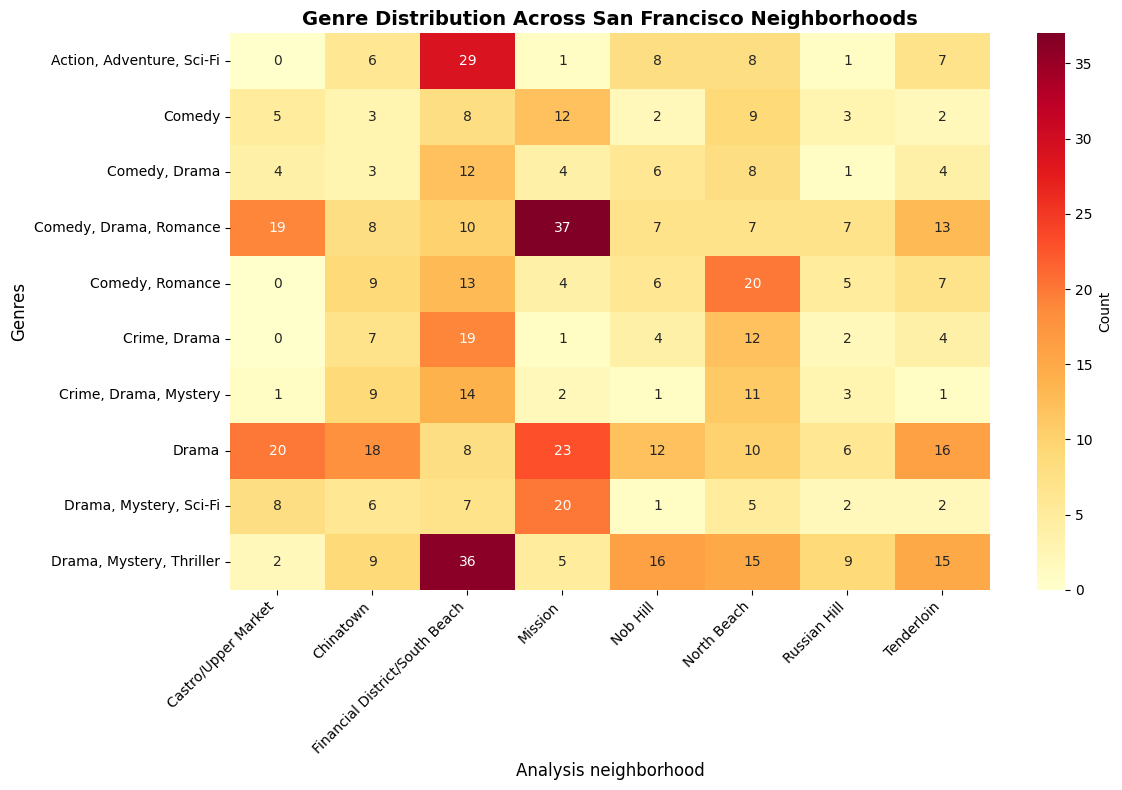



Genre-Neighborhood Crosstab (top genres and neighborhoods):
Analysis neighborhood      Castro/Upper Market  Chinatown  \
Genres                                                      
Action, Adventure, Sci-Fi                    0          6   
Comedy                                       5          3   
Comedy, Drama                                4          3   
Comedy, Drama, Romance                      19          8   
Comedy, Romance                              0          9   
Crime, Drama                                 0          7   
Crime, Drama, Mystery                        1          9   
Drama                                       20         18   
Drama, Mystery, Sci-Fi                       8          6   
Drama, Mystery, Thriller                     2          9   

Analysis neighborhood      Financial District/South Beach  Mission  Nob Hill  \
Genres                                                                         
Action, Adventure, Sci-Fi                    

In [4]:
# Create cross-tabulation: Genres vs Neighborhoods (for top items)
import matplotlib.pyplot as plt
import seaborn as sns

# Select top 8 neighborhoods and top 10 genres
top_n_neighborhoods = 8
top_n_genres = 10

top_neighborhoods = df['Analysis neighborhood'].value_counts().head(top_n_neighborhoods).index
top_genres = df['Genres'].value_counts().head(top_n_genres).index

# Filter data for heatmap
heatmap_data = df[
    (df['Analysis neighborhood'].isin(top_neighborhoods)) & 
    (df['Genres'].isin(top_genres))
]

# Create crosstab
crosstab = pd.crosstab(heatmap_data['Genres'], heatmap_data['Analysis neighborhood'])

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Count'})
plt.title('Genre Distribution Across San Francisco Neighborhoods', fontsize=14, fontweight='bold')
plt.xlabel('Analysis neighborhood', fontsize=12)
plt.ylabel('Genres', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\n\nGenre-Neighborhood Crosstab (top genres and neighborhoods):")
print(crosstab)

In [5]:
# Specific genre analysis - example with Horror, Thriller, Comedy
genres_to_analyze = ['Horror', 'Thriller', 'Comedy', 'Drama', 'Action']

print("GENRE CONCENTRATION BY NEIGHBORHOOD")
print("=" * 70)

for genre in genres_to_analyze:
    genre_subset = df[df['Genres'] == genre]
    
    if len(genre_subset) > 0:
        neighborhood_dist = genre_subset['Analysis neighborhood'].value_counts()
        
        print(f"\n\n{genre.upper()} - Total: {len(genre_subset)} films")
        print(f"{'-' * 70}")
        print(f"Top neighborhoods where '{genre}' is filmed:")
        
        for i, (neighborhood, count) in enumerate(neighborhood_dist.head(5).items(), 1):
            percentage = (count / len(genre_subset)) * 100
            print(f"  {i}. {neighborhood:<25} : {count:3d} ({percentage:5.1f}%)")
        
        # Calculate concentration (max neighborhood % / average if distributed evenly)
        max_concentration = (neighborhood_dist.iloc[0] / len(genre_subset)) * 100
        avg_if_even = (100 / len(neighborhood_dist))
        concentration_ratio = max_concentration / avg_if_even
        print(f"\n     Concentration ratio: {concentration_ratio:.2f}x (1.0 = evenly distributed)")

GENRE CONCENTRATION BY NEIGHBORHOOD


COMEDY - Total: 75 films
----------------------------------------------------------------------
Top neighborhoods where 'Comedy' is filmed:
  1. Mission                   :  12 ( 16.0%)
  2. North Beach               :   9 ( 12.0%)
  3. Financial District/South Beach :   8 ( 10.7%)
  4. Castro/Upper Market       :   5 (  6.7%)
  5. Bernal Heights            :   4 (  5.3%)

     Concentration ratio: 3.52x (1.0 = evenly distributed)


DRAMA - Total: 192 films
----------------------------------------------------------------------
Top neighborhoods where 'Drama' is filmed:
  1. Mission                   :  23 ( 12.0%)
  2. Castro/Upper Market       :  20 ( 10.4%)
  3. Chinatown                 :  18 (  9.4%)
  4. Tenderloin                :  16 (  8.3%)
  5. Nob Hill                  :  12 (  6.2%)

     Concentration ratio: 3.71x (1.0 = evenly distributed)


In [6]:
# Analyze genre distribution by neighborhood (top neighborhoods)
top_neighborhoods = df['Analysis neighborhood'].value_counts().head(8).index

genre_by_neighborhood = {}

for neighborhood in top_neighborhoods:
    # Get all genres for this neighborhood
    genres_in_neighborhood = df[df['Analysis neighborhood'] == neighborhood]['Genres'].value_counts()
    genre_by_neighborhood[neighborhood] = genres_in_neighborhood.head(5)

# Display the results
for neighborhood, genres in genre_by_neighborhood.items():
    print(f"\n{'='*50}")
    print(f"NEIGHBORHOOD: {neighborhood}")
    print(f"{'='*50}")
    for genre, count in genres.items():
        print(f"  {genre:<30} : {count:3d} films")


NEIGHBORHOOD: Financial District/South Beach
  Drama, Mystery, Thriller       :  36 films
  Action, Adventure, Sci-Fi      :  29 films
  Crime, Drama                   :  19 films
  Crime, Drama, Mystery          :  14 films
  Biography, Drama               :  14 films

NEIGHBORHOOD: North Beach
  Comedy, Romance                :  20 films
  Drama, Mystery, Thriller       :  15 films
  Crime, Drama                   :  12 films
  Crime, Drama, Mystery          :  11 films
  Drama                          :  10 films

NEIGHBORHOOD: Nob Hill
  Drama, Mystery, Thriller       :  16 films
  Drama                          :  12 films
  Action, Adventure, Sci-Fi      :   8 films
  Comedy, Drama, Romance         :   7 films
  Action, Adventure, Fantasy     :   7 films

NEIGHBORHOOD: Chinatown
  Drama                          :  18 films
  Action, Crime, Mystery         :  10 films
  Crime, Drama, Mystery          :   9 films
  Drama, Mystery, Thriller       :   9 films
  Comedy, Romance      

In [7]:
# Create a detailed genre-neighborhood analysis
import numpy as np

# Split genres for each movie (they're comma-separated)
genre_neighborhood_data = []

for idx, row in df.iterrows():
    if pd.notna(row['Genres']) and pd.notna(row['Analysis neighborhood']):
        # Split genres by comma and strip whitespace
        genres = [g.strip() for g in str(row['Genres']).split(',')]
        neighborhood = row['Analysis neighborhood']
        
        # Create one record per genre
        for genre in genres:
            genre_neighborhood_data.append({
                'Genre': genre,
                'Neighborhood': neighborhood,
                'Title': row['Title']
            })

genre_df = pd.DataFrame(genre_neighborhood_data)
print(f"Total genre entries created: {len(genre_df)}")
print(f"\n\nPrimary genres in the dataset:")
print(genre_df['Genre'].value_counts().head(15))

Total genre entries created: 5216


Primary genres in the dataset:
Genre
Drama        1353
Comedy        740
Mystery       507
Romance       494
Crime         446
Thriller      412
Action        369
Sci-Fi        284
Adventure     216
Biography     106
Fantasy        83
Family         72
Film-Noir      38
Horror         28
Music          18
Name: count, dtype: int64


In [8]:
# Parse genres and create a genre-neighborhood relationship
# Handle multi-genre entries by splitting them

# First, let's see how many movies per neighborhood
neighborhoods = df['Analysis neighborhood'].value_counts()
print(f"Total neighborhoods: {len(neighborhoods)}")
print(f"\nTop neighborhoods by count:\n{neighborhoods.head(10)}")

# Check genres column
print(f"\n\nTotal movies/shows: {len(df)}")
print(f"Movies/shows with genre info: {df['Genres'].notna().sum()}")
print(f"\nSample genres:\n{df['Genres'].head(10).values}")

Total neighborhoods: 40

Top neighborhoods by count:
Analysis neighborhood
Financial District/South Beach    312
North Beach                       205
Nob Hill                          165
Chinatown                         165
Mission                           153
Tenderloin                        142
Russian Hill                       87
Castro/Upper Market                87
South of Market                    83
Potrero Hill                       76
Name: count, dtype: int64


Total movies/shows: 2244
Movies/shows with genre info: 2244

Sample genres:
<StringArray>
['Biography, Drama, History',  'Drama, Mystery, Thriller',
    'Crime, Drama, Thriller',                     'Drama',
                     'Drama',      'Action, Crime, Drama',
    'Drama, Mystery, Sci-Fi',      'Action, Crime, Drama',
     'Crime, Drama, Mystery',    'Drama, Mystery, Sci-Fi']
Length: 10, dtype: str


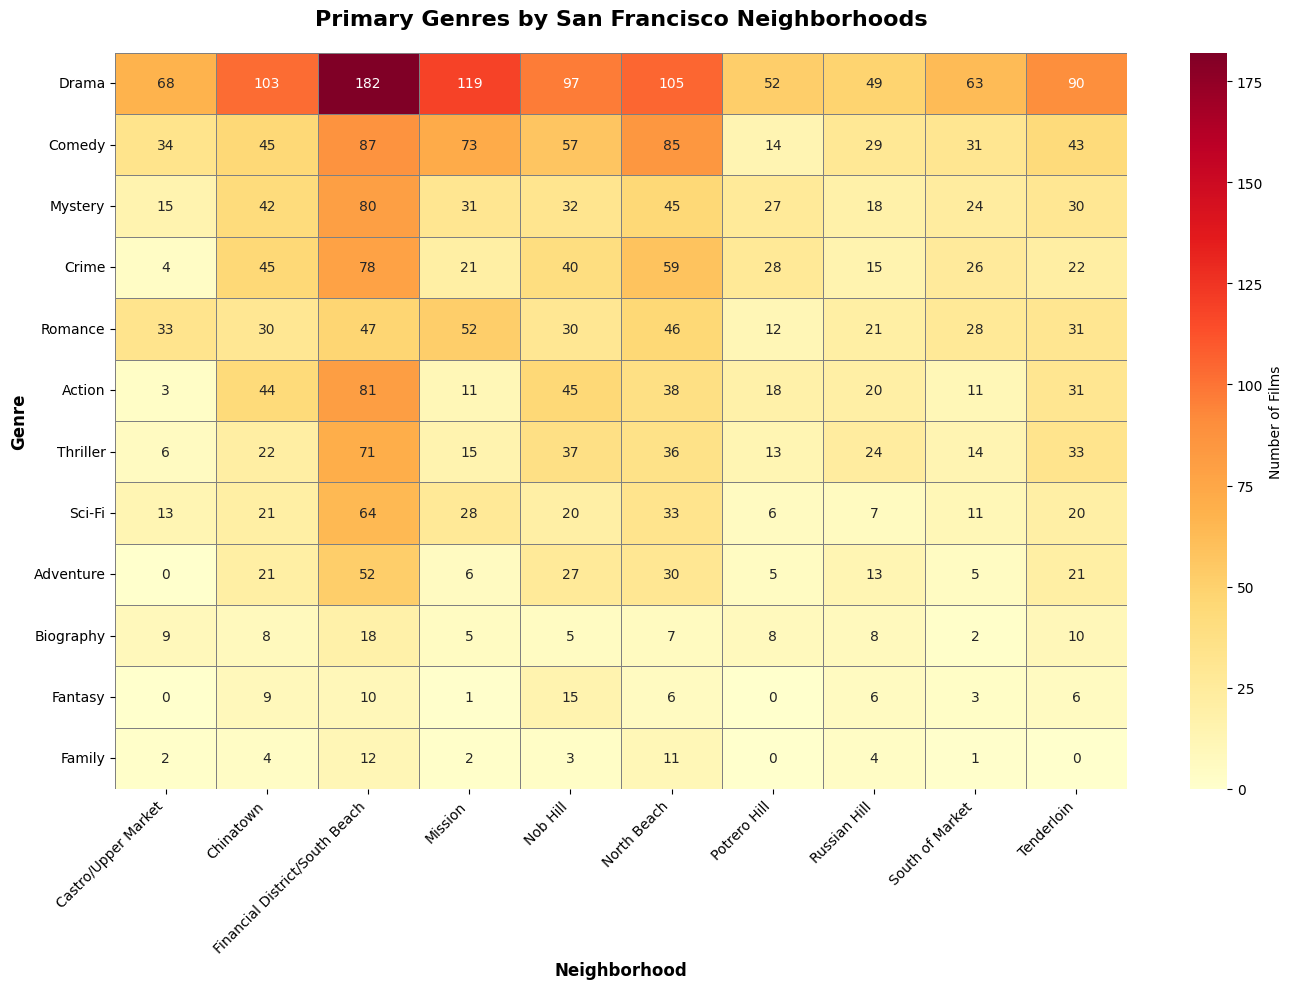


📊 GENRES BY NEIGHBORHOOD (Top 12 genres × Top 10 neighborhoods)
Neighborhood  Castro/Upper Market  Chinatown  Financial District/South Beach  \
Genre                                                                          
Drama                          68        103                             182   
Comedy                         34         45                              87   
Mystery                        15         42                              80   
Crime                           4         45                              78   
Romance                        33         30                              47   
Action                          3         44                              81   
Thriller                        6         22                              71   
Sci-Fi                         13         21                              64   
Adventure                       0         21                              52   
Biography                       9          8           

In [9]:
# Create a comprehensive heatmap of primary genres by neighborhoods
import matplotlib.pyplot as plt
import seaborn as sns

# Select top 10 neighborhoods and top 12 genres
top_n_neighborhoods = 10
top_n_genres = 12

top_neighborhoods_list = genre_df['Neighborhood'].value_counts().head(top_n_neighborhoods).index.tolist()
top_genres_list = genre_df['Genre'].value_counts().head(top_n_genres).index.tolist()

# Filter genre_df for the top items
filtered_genre_df = genre_df[
    (genre_df['Neighborhood'].isin(top_neighborhoods_list)) & 
    (genre_df['Genre'].isin(top_genres_list))
]

# Create crosstab - Genre (rows) vs Neighborhood (columns)
genre_neighborhood_crosstab = pd.crosstab(
    filtered_genre_df['Genre'], 
    filtered_genre_df['Neighborhood']
)

# Sort by total count (descending)
genre_neighborhood_crosstab = genre_neighborhood_crosstab.loc[
    genre_neighborhood_crosstab.sum(axis=1).sort_values(ascending=False).index
]

# Create the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    genre_neighborhood_crosstab, 
    annot=True,  # Show values
    fmt='d',  # Integer format
    cmap='YlOrRd', 
    cbar_kws={'label': 'Number of Films'},
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Primary Genres by San Francisco Neighborhoods', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Neighborhood', fontsize=12, fontweight='bold')
plt.ylabel('Genre', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n📊 GENRES BY NEIGHBORHOOD (Top 12 genres × Top 10 neighborhoods)")
print("=" * 80)
print(genre_neighborhood_crosstab)
print("\n")
print(f"Row totals (total films per genre):")
print(genre_neighborhood_crosstab.sum(axis=1).sort_values(ascending=False))

In [10]:
# Correlation analysis: Which actors are most concentrated in specific neighborhoods?
print(f"\n\n{'='*80}")
print("🔍 ACTOR-NEIGHBORHOOD SPECIALIZATION ANALYSIS")
print(f"{'='*80}\n")

top_n = 10
top_actors_list = df['Actor 1'].value_counts().head(top_n).index.tolist()

for actor in top_actors_list:
    actor_data = df[df['Actor 1'] == actor]
    neighborhood_dist = actor_data['Analysis neighborhood'].value_counts()
    
    # Calculate concentration metrics
    total_roles = len(actor_data)
    max_neighborhood_roles = neighborhood_dist.iloc[0]
    max_neighborhood = neighborhood_dist.index[0]
    
    concentration_percentage = (max_neighborhood_roles / total_roles) * 100
    concentration_ratio = concentration_percentage / (100 / len(neighborhood_dist))
    
    print(f"{actor}")
    print(f"  Total roles: {total_roles}")
    print(f"  Strongest neighborhood: {max_neighborhood} ({max_neighborhood_roles} roles - {concentration_percentage:.1f}%)")
    print(f"  Concentration ratio: {concentration_ratio:.2f}x (1.0 = evenly distributed)")
    print(f"  Active in {len(neighborhood_dist)} different neighborhoods")
    print()



🔍 ACTOR-NEIGHBORHOOD SPECIALIZATION ANALYSIS

Jonathan Groff
  Total roles: 125
  Strongest neighborhood: Mission (30 roles - 24.0%)
  Concentration ratio: 5.76x (1.0 = evenly distributed)
  Active in 24 different neighborhoods

Hugh Laurie
  Total roles: 114
  Strongest neighborhood: North Beach (12 roles - 10.5%)
  Concentration ratio: 2.63x (1.0 = evenly distributed)
  Active in 25 different neighborhoods

Clint Eastwood
  Total roles: 80
  Strongest neighborhood: Potrero Hill (9 roles - 11.2%)
  Concentration ratio: 2.36x (1.0 = evenly distributed)
  Active in 21 different neighborhoods

Don Johnson
  Total roles: 60
  Strongest neighborhood: Financial District/South Beach (18 roles - 30.0%)
  Concentration ratio: 2.70x (1.0 = evenly distributed)
  Active in 9 different neighborhoods

Taye Diggs
  Total roles: 58
  Strongest neighborhood: Potrero Hill (8 roles - 13.8%)
  Concentration ratio: 2.48x (1.0 = evenly distributed)
  Active in 18 different neighborhoods

Jamie Clayton
  

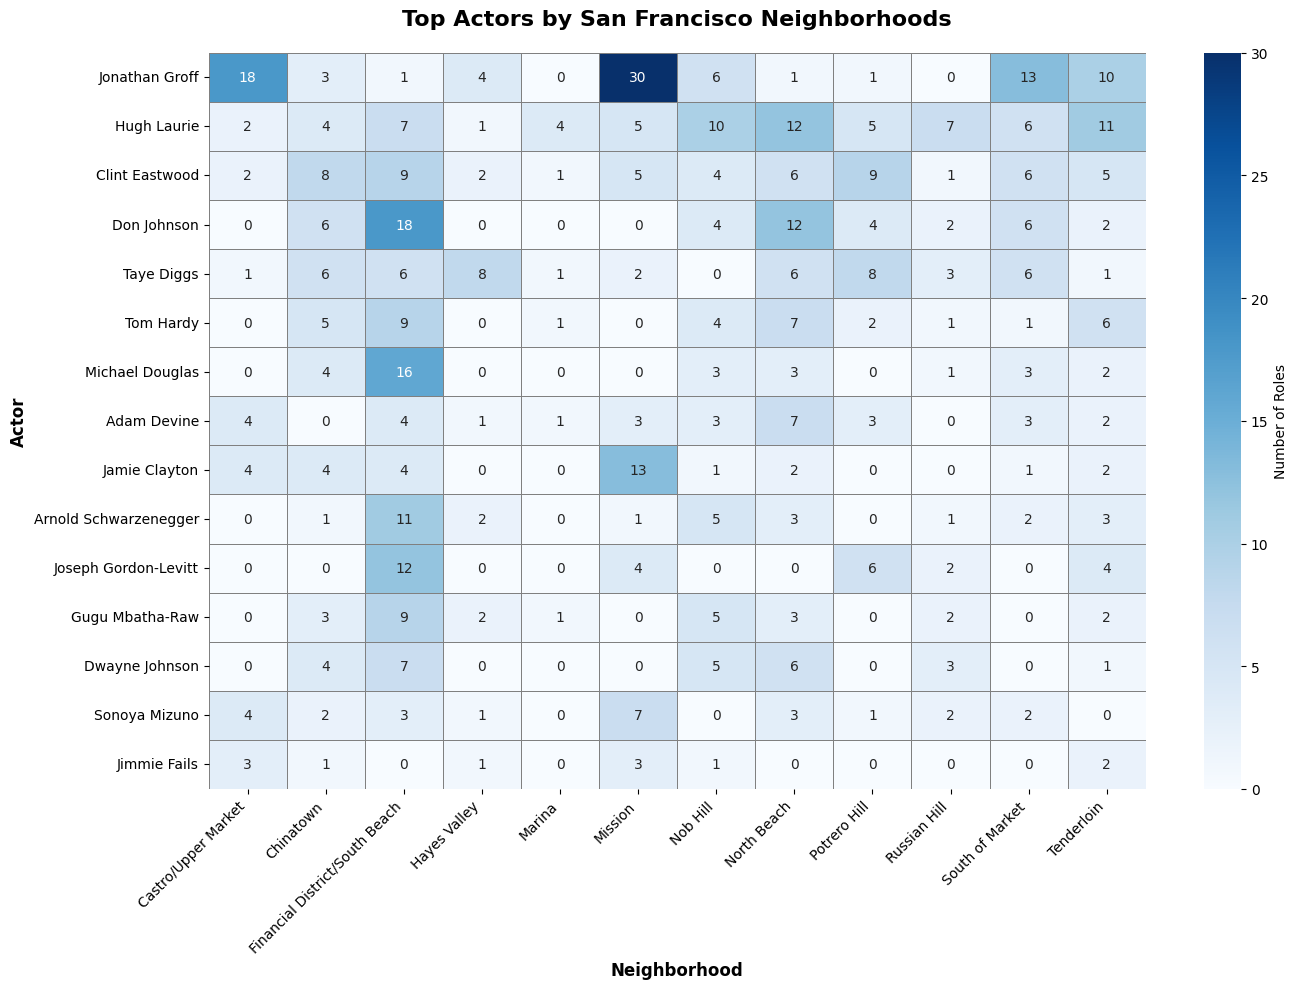


📊 ACTORS BY NEIGHBORHOOD (Top 15 actors × Top 12 neighborhoods)
Analysis neighborhood  Castro/Upper Market  Chinatown  \
Actor 1                                                 
Jonathan Groff                          18          3   
Hugh Laurie                              2          4   
Clint Eastwood                           2          8   
Don Johnson                              0          6   
Taye Diggs                               1          6   
Tom Hardy                                0          5   
Michael Douglas                          0          4   
Adam Devine                              4          0   
Jamie Clayton                            4          4   
Arnold Schwarzenegger                    0          1   
Joseph Gordon-Levitt                     0          0   
Gugu Mbatha-Raw                          0          3   
Dwayne Johnson                           0          4   
Sonoya Mizuno                            4          2   
Jimmie Fails           

In [11]:
# Create a heatmap: Actors vs Neighborhoods (for top actors and neighborhoods)
import matplotlib.pyplot as plt
import seaborn as sns

top_n_actors = 15
top_n_neighborhoods = 12

top_actors_list = df['Actor 1'].value_counts().head(top_n_actors).index.tolist()
top_neighborhoods_actor = df['Analysis neighborhood'].value_counts().head(top_n_neighborhoods).index.tolist()

# Filter data for heatmap
filtered_actor_df = df[
    (df['Actor 1'].isin(top_actors_list)) & 
    (df['Analysis neighborhood'].isin(top_neighborhoods_actor))
]

# Create crosstab - Actor (rows) vs Neighborhood (columns)
actor_neighborhood_crosstab = pd.crosstab(
    filtered_actor_df['Actor 1'], 
    filtered_actor_df['Analysis neighborhood']
)

# Sort by total count
actor_neighborhood_crosstab = actor_neighborhood_crosstab.loc[
    actor_neighborhood_crosstab.sum(axis=1).sort_values(ascending=False).index
]

# Create the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    actor_neighborhood_crosstab, 
    annot=True,
    fmt='d',
    cmap='Blues', 
    cbar_kws={'label': 'Number of Roles'},
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Top Actors by San Francisco Neighborhoods', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Neighborhood', fontsize=12, fontweight='bold')
plt.ylabel('Actor', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n📊 ACTORS BY NEIGHBORHOOD (Top 15 actors × Top 12 neighborhoods)")
print("=" * 100)
print(actor_neighborhood_crosstab)
print("\n")
print(f"Total roles per actor (row totals):")
print(actor_neighborhood_crosstab.sum(axis=1).sort_values(ascending=False))

In [12]:
# Analyze neighborhood distribution for top actors
top_n_actors = 15
top_actors_list = df['Actor 1'].value_counts().head(top_n_actors).index.tolist()

print(f"\n\n{'='*80}")
print(f"NEIGHBORHOOD DISTRIBUTION FOR TOP {top_n_actors} ACTORS")
print(f"{'='*80}")

for actor in top_actors_list:
    actor_data = df[df['Actor 1'] == actor]
    neighborhood_dist = actor_data['Analysis neighborhood'].value_counts()
    total_roles = len(actor_data)
    
    print(f"\n{actor} ({total_roles} roles):")
    print(f"  {'-'*70}")
    for i, (neighborhood, count) in enumerate(neighborhood_dist.head(5).items(), 1):
        percentage = (count / total_roles) * 100
        bar = '█' * int(percentage / 5)
        print(f"  {i}. {neighborhood:<25} : {count:2d} ({percentage:5.1f}%) {bar}")



NEIGHBORHOOD DISTRIBUTION FOR TOP 15 ACTORS

Jonathan Groff (125 roles):
  ----------------------------------------------------------------------
  1. Mission                   : 30 ( 24.0%) ████
  2. Castro/Upper Market       : 18 ( 14.4%) ██
  3. South of Market           : 13 ( 10.4%) ██
  4. Tenderloin                : 10 (  8.0%) █
  5. Haight Ashbury            :  8 (  6.4%) █

Hugh Laurie (114 roles):
  ----------------------------------------------------------------------
  1. North Beach               : 12 ( 10.5%) ██
  2. Haight Ashbury            : 11 (  9.6%) █
  3. Tenderloin                : 11 (  9.6%) █
  4. Nob Hill                  : 10 (  8.8%) █
  5. Russian Hill              :  7 (  6.1%) █

Clint Eastwood (80 roles):
  ----------------------------------------------------------------------
  1. Potrero Hill              :  9 ( 11.2%) ██
  2. Financial District/South Beach :  9 ( 11.2%) ██
  3. Chinatown                 :  8 ( 10.0%) ██
  4. South of Market       

In [13]:
# Extract all actors and create actor-neighborhood relationship
actor_neighborhood_data = []

# Extract from Actor 1, Actor 2, and Actor 3 columns
for actor_col in ['Actor 1', 'Actor 2', 'Actor 3']:
    for idx, row in df.iterrows():
        if pd.notna(row[actor_col]) and pd.notna(row['Analysis neighborhood']):
            actor_name = str(row[actor_col]).strip()
            neighborhood = str(row['Analysis neighborhood']).strip()
            
            # Only add if actor name is not empty
            if actor_name and actor_name.lower() != 'nan':
                actor_neighborhood_data.append({
                    'Actor': actor_name,
                    'Analysis neighborhood': neighborhood,
                    'Title': row['Title'],
                    'Actor_Column': actor_col
                })

actor_df = pd.DataFrame(actor_neighborhood_data)

print(f"Total actor entries created: {len(actor_df)}")
print(f"Unique actors: {actor_df['Actor'].nunique()}")
print(f"Unique neighborhoods: {actor_df['Analysis neighborhood'].nunique()}")

print(f"\n\n{'='*70}")
print("🎭 TOP 20 ACTORS BY ROLES IN SAN FRANCISCO FILMS")
print(f"{'='*70}")
top_actors = actor_df['Actor'].value_counts().head(20)
for rank, (actor, count) in enumerate(top_actors.items(), 1):
    print(f"{rank:2d}. {actor:<35} : {count:3d} roles")

Total actor entries created: 5820
Unique actors: 562
Unique neighborhoods: 40


🎭 TOP 20 ACTORS BY ROLES IN SAN FRANCISCO FILMS
 1. Murray Bartlett                     : 138 roles
 2. Jonathan Groff                      : 120 roles
 3. Hugh Laurie                         : 112 roles
 4. Ethan Suplee                        : 112 roles
 5. Gretchen Mol                        :  84 roles
 6. Frankie Alvarez                     :  84 roles
 7. Clint Eastwood                      :  75 roles
 8. Keanu Reeves                        :  67 roles
 9. Michael Douglas                     :  63 roles
10. Taye Diggs                          :  59 roles
11. Don Johnson                         :  58 roles
12. Kathleen Robertson                  :  58 roles
13. Cheech Marin                        :  58 roles
14. Ian Anthony Dale                    :  58 roles
15. Joe Dinicol                         :  58 roles
16. Danny Glover                        :  53 roles
17. Jamie Clayton                       

## Actor Analysis

Analyzing which actors played the most roles in San Francisco films and their neighborhood distributions.

In [14]:
# Find the most present actor in the dataset
most_present_actor = actor_df['Actor'].value_counts().iloc[0]
actor_name = actor_df['Actor'].value_counts().index[0]

print(f"\n{'='*70}")
print("🌟 MOST PRESENT ACTOR IN THE DATASET")
print(f"{'='*70}\n")
print(f"Actor: {actor_name}")
print(f"Total roles: {most_present_actor}")
print(f"\nNeighborhouses where {actor_name} filmed:")

actor_neighborhoods = actor_df[actor_df['Actor'] == actor_name]['Analysis neighborhood'].value_counts()
for i, (neighborhood, count) in enumerate(actor_neighborhoods.items(), 1):
    percentage = (count / most_present_actor) * 100
    print(f"  {i}. {neighborhood:<30} : {count:2d} roles ({percentage:5.1f}%)")


🌟 MOST PRESENT ACTOR IN THE DATASET

Actor: Murray Bartlett
Total roles: 138

Neighborhouses where Murray Bartlett filmed:
  1. Mission                        : 34 roles ( 24.6%)
  2. Castro/Upper Market            : 23 roles ( 16.7%)
  3. South of Market                : 13 roles (  9.4%)
  4. Tenderloin                     : 11 roles (  8.0%)
  5. Haight Ashbury                 :  8 roles (  5.8%)
  6. Nob Hill                       :  6 roles (  4.3%)
  7. North Beach                    :  5 roles (  3.6%)
  8. Chinatown                      :  5 roles (  3.6%)
  9. Mission Bay                    :  4 roles (  2.9%)
  10. Pacific Heights                :  4 roles (  2.9%)
  11. Hayes Valley                   :  4 roles (  2.9%)
  12. Outer Mission                  :  3 roles (  2.2%)
  13. Lakeshore                      :  2 roles (  1.4%)
  14. Presidio                       :  2 roles (  1.4%)
  15. Treasure Island                :  2 roles (  1.4%)
  16. Outer Richmond          

In [4]:
# Filter dataset to unique film titles and find most common actor
df_unique = df.drop_duplicates(subset=['Title']).reset_index(drop=True)

print(f"Original dataset rows: {len(df)}")
print(f"Unique film titles: {len(df_unique)}")

# Collect all actors from Actor 1, 2, 3 columns
all_actors_unique = []

for actor_col in ['Actor 1', 'Actor 2', 'Actor 3']:
    for actor in df_unique[actor_col].dropna():
        actor_name = str(actor).strip()
        if actor_name and actor_name.lower() != 'nan':
            all_actors_unique.append(actor_name)

# Get actor counts
actor_counts = pd.Series(all_actors_unique).value_counts()

print(f"\n\n{'='*70}")
print("🌟 MOST COMMON ACTOR (ACROSS UNIQUE FILM TITLES)")
print(f"{'='*70}\n")

most_common = actor_counts.index[0]
most_common_count = actor_counts.iloc[0]

print(f"Actor: {most_common}")
print(f"Appearances across Actor 1, 2, 3: {most_common_count}")

print(f"\n\nTop 15 Most Common Actors:")
print(f"{'-'*70}")
for rank, (actor, count) in enumerate(actor_counts.head(15).items(), 1):
    print(f"{rank:2d}. {actor:<35} : {count:3d} appearances")

Original dataset rows: 2244
Unique film titles: 316


🌟 MOST COMMON ACTOR (ACROSS UNIQUE FILM TITLES)

Actor: Robin Williams
Appearances across Actor 1, 2, 3: 8


Top 15 Most Common Actors:
----------------------------------------------------------------------
 1. Robin Williams                      :   8 appearances
 2. Clint Eastwood                      :   6 appearances
 3. Sean Penn                           :   5 appearances
 4. Keanu Reeves                        :   5 appearances
 5. Eddie Murphy                        :   5 appearances
 6. Meg Ryan                            :   5 appearances
 7. Julia Roberts                       :   4 appearances
 8. Michael Douglas                     :   4 appearances
 9. Sean Connery                        :   4 appearances
10. Sidney Poitier                      :   3 appearances
11. Whoopi Goldberg                     :   3 appearances
12. Paul Rudd                           :   3 appearances
13. Richard Dreyfuss                    :  

In [16]:
# Count unique titles in the dataset
unique_titles = df['Title'].nunique()
total_rows = len(df)

print(f"\n{'='*70}")
print("📊 DATASET TITLE STATISTICS")
print(f"{'='*70}\n")
print(f"Total rows in dataset: {total_rows}")
print(f"Unique film/show titles: {unique_titles}")
print(f"Duplicate entries: {total_rows - unique_titles}")
print(f"Percentage of unique titles: {(unique_titles / total_rows * 100):.1f}%")


📊 DATASET TITLE STATISTICS

Total rows in dataset: 2244
Unique film/show titles: 316
Duplicate entries: 1928
Percentage of unique titles: 14.1%


## Genre Analysis (Unique Titles Only)

Analyzing genres using only unique film titles (316 titles).

In [17]:
# Genre analysis for unique titles - split and analyze individual genres
import pandas as pd
import numpy as np

# Create genre-neighborhood dataset for unique titles
genre_neighborhood_data_unique = []

for idx, row in df_unique.iterrows():
    if pd.notna(row['Genres']) and pd.notna(row['Analysis neighborhood']):
        # Split genres by comma and strip whitespace
        genres = [g.strip() for g in str(row['Genres']).split(',')]
        neighborhood = row['Analysis neighborhood']
        
        # Create one record per genre
        for genre in genres:
            genre_neighborhood_data_unique.append({
                'Genre': genre,
                'Analysis neighborhood': neighborhood,
                'Title': row['Title']
            })

genre_df_unique = pd.DataFrame(genre_neighborhood_data_unique)

print(f"Analysis on {len(df_unique)} unique titles:")
print(f"Total genre entries: {len(genre_df_unique)}")
print(f"Unique genres: {genre_df_unique['Genre'].nunique()}")

print(f"\n\n{'='*70}")
print("🎬 TOP 20 GENRES (UNIQUE TITLES)")
print(f"{'='*70}")
top_genres_unique = genre_df_unique['Genre'].value_counts().head(20)
for rank, (genre, count) in enumerate(top_genres_unique.items(), 1):
    print(f"{rank:2d}. {genre:<30} : {count:3d} films")

Analysis on 316 unique titles:
Total genre entries: 585
Unique genres: 22


🎬 TOP 20 GENRES (UNIQUE TITLES)
 1. Drama                          : 145 films
 2. Comedy                         :  97 films
 3. Romance                        :  60 films
 4. Crime                          :  47 films
 5. Action                         :  36 films
 6. Mystery                        :  33 films
 7. Thriller                       :  32 films
 8. Adventure                      :  23 films
 9. Sci-Fi                         :  22 films
10. Biography                      :  19 films
11. Fantasy                        :  17 films
12. Family                         :  13 films
13. Music                          :   8 films
14. Film-Noir                      :   8 films
15. Horror                         :   7 films
16. Musical                        :   5 films
17. History                        :   4 films
18. Documentary                    :   3 films
19. Sport                          :   2 films

In [17]:
# Analyze genre distribution by neighborhood for unique titles
top_neighborhoods_unique = df_unique['Analysis neighborhood'].value_counts().head(10).index

genre_by_neighborhood_unique = {}

for neighborhood in top_neighborhoods_unique:
    # Get all genres for this neighborhood in unique titles
    movies = df_unique[df_unique['Analysis neighborhood'] == neighborhood]
    genres_list = []
    for genres_str in movies['Genres'].dropna():
        genres_list.extend([g.strip() for g in str(genres_str).split(',')])
    genres_in_neighborhood = pd.Series(genres_list).value_counts()
    genre_by_neighborhood_unique[neighborhood] = genres_in_neighborhood.head(5)

# Display the results
print(f"\n\n{'='*70}")
print("GENRE DISTRIBUTION BY NEIGHBORHOOD (UNIQUE TITLES)")
print(f"{'='*70}")

for neighborhood, genres in genre_by_neighborhood_unique.items():
    print(f"\n{'='*50}")
    print(f"NEIGHBORHOOD: {neighborhood}")
    print(f"{'='*50}")
    for genre, count in genres.items():
        print(f"  {genre:<30} : {count:3d} films")



GENRE DISTRIBUTION BY NEIGHBORHOOD (UNIQUE TITLES)

NEIGHBORHOOD: Financial District/South Beach
  Drama                          :  23 films
  Comedy                         :  15 films
  Thriller                       :   7 films
  Crime                          :   7 films
  Mystery                        :   6 films

NEIGHBORHOOD: North Beach
  Comedy                         :  14 films
  Drama                          :  12 films
  Romance                        :   8 films
  Crime                          :   5 films
  Action                         :   5 films

NEIGHBORHOOD: Nob Hill
  Drama                          :  13 films
  Comedy                         :   9 films
  Crime                          :   8 films
  Action                         :   6 films
  Thriller                       :   5 films

NEIGHBORHOOD: Tenderloin
  Drama                          :  12 films
  Comedy                         :   7 films
  Romance                        :   6 films
  Thriller    

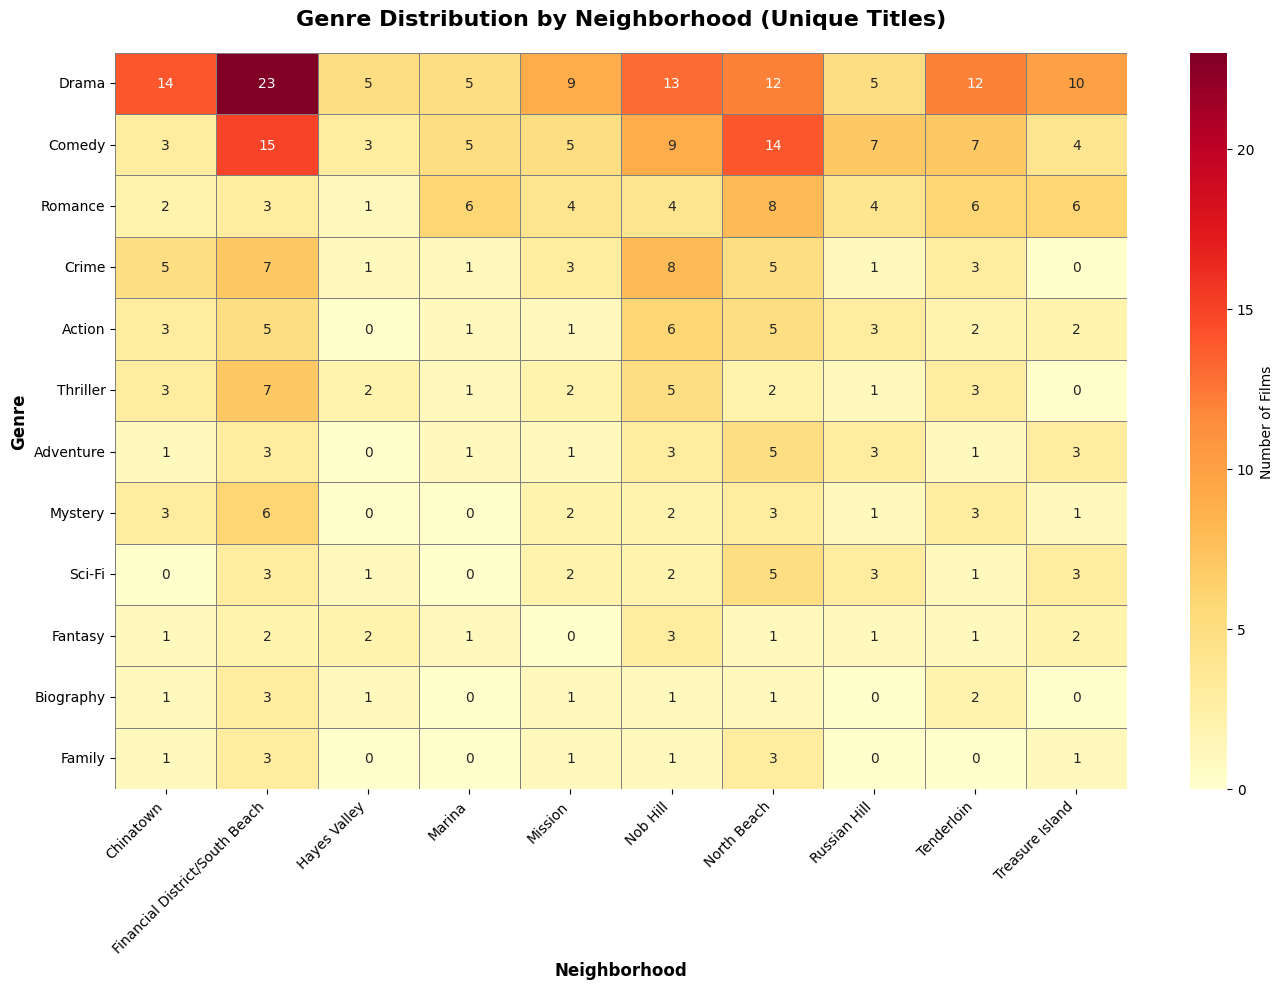


📊 GENRES BY NEIGHBORHOOD - UNIQUE TITLES ONLY (Top 12 genres × Top 10 neighborhoods)
Analysis neighborhood  Chinatown  Financial District/South Beach  \
Genre                                                              
Drama                         14                              23   
Comedy                         3                              15   
Romance                        2                               3   
Crime                          5                               7   
Action                         3                               5   
Thriller                       3                               7   
Adventure                      1                               3   
Mystery                        3                               6   
Sci-Fi                         0                               3   
Fantasy                        1                               2   
Biography                      1                               3   
Family                        

In [18]:
# Create a comprehensive heatmap of genres by neighborhoods for unique titles
import matplotlib.pyplot as plt
import seaborn as sns

# Select top 10 neighborhoods and top 12 genres
top_n_neighborhoods = 10
top_n_genres = 12

top_neighborhoods_list = genre_df_unique['Analysis neighborhood'].value_counts().head(top_n_neighborhoods).index.tolist()
top_genres_list = genre_df_unique['Genre'].value_counts().head(top_n_genres).index.tolist()

# Filter genre_df for the top items
filtered_genre_df_unique = genre_df_unique[
    (genre_df_unique['Analysis neighborhood'].isin(top_neighborhoods_list)) & 
    (genre_df_unique['Genre'].isin(top_genres_list))
]

# Create crosstab - Genre (rows) vs Neighborhood (columns)
genre_neighborhood_crosstab_unique = pd.crosstab(
    filtered_genre_df_unique['Genre'], 
    filtered_genre_df_unique['Analysis neighborhood']
)

# Sort by total count (descending)
genre_neighborhood_crosstab_unique = genre_neighborhood_crosstab_unique.loc[
    genre_neighborhood_crosstab_unique.sum(axis=1).sort_values(ascending=False).index
]

# Create the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    genre_neighborhood_crosstab_unique, 
    annot=True,  # Show values
    fmt='d',  # Integer format
    cmap='YlOrRd', 
    cbar_kws={'label': 'Number of Films'},
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Genre Distribution by Neighborhood (Unique Titles)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Neighborhood', fontsize=12, fontweight='bold')
plt.ylabel('Genre', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n📊 GENRES BY NEIGHBORHOOD - UNIQUE TITLES ONLY (Top 12 genres × Top 10 neighborhoods)")
print("=" * 80)
print(genre_neighborhood_crosstab_unique)
print("\n")
print(f"Row totals (total films per genre):")
print(genre_neighborhood_crosstab_unique.sum(axis=1).sort_values(ascending=False))

## Interactive Genre Map

Explore movie concentrations by genre using an interactive map of San Francisco neighborhoods.

In [19]:
import plotly.graph_objects as go
import plotly.express as px

# San Francisco neighborhoods with approximate lat/lon coordinates
sf_neighborhoods = {
    'Chinatown': {'lat': 37.7958, 'lon': -122.4075},
    'Financial District/South Beach': {'lat': 37.7913, 'lon': -122.3975},
    'Mission': {'lat': 37.7599, 'lon': -122.4148},
    'North Beach': {'lat': 37.8064, 'lon': -122.4124},
    'Nob Hill': {'lat': 37.7922, 'lon': -122.4087},
    'Hayes Valley': {'lat': 37.7744, 'lon': -122.4267},
    'Marina': {'lat': 37.8017, 'lon': -122.4368},
    'Tenderloin': {'lat': 37.7850, 'lon': -122.4162},
    'Russian Hill': {'lat': 37.7943, 'lon': -122.4212},
    'Treasure Island': {'lat': 37.8158, 'lon': -122.3716},
    'Richmond': {'lat': 37.7768, 'lon': -122.4684},
    'Sunset': {'lat': 37.7603, 'lon': -122.4583},
    'Western Addition': {'lat': 37.7816, 'lon': -122.4406},
    'Pacific Heights': {'lat': 37.7990, 'lon': -122.4369},
    'Castro': {'lat': 37.7599, 'lon': -122.4347},
    'South of Market': {'lat': 37.7785, 'lon': -122.3975},
    'Visitacion Valley': {'lat': 37.7276, 'lon': -122.3861},
    'Bayview': {'lat': 37.7356, 'lon': -122.3720},
    'Excelsior': {'lat': 37.7245, 'lon': -122.4062},
}

# Get list of all unique genres
all_genres = sorted(genre_df_unique['Genre'].unique())

print(f"Available genres: {len(all_genres)}")
print(f"Neighborhoods with coordinates: {len(sf_neighborhoods)}")
print(f"\nGenres: {', '.join(all_genres[:10])}...")
print(f"\nNeighborhoods: {', '.join(list(sf_neighborhoods.keys())[:5])}...")

Available genres: 22
Neighborhoods with coordinates: 19

Genres: Action, Adventure, Biography, Comedy, Crime, Documentary, Drama, Family, Fantasy, Film-Noir...

Neighborhoods: Chinatown, Financial District/South Beach, Mission, North Beach, Nob Hill...


In [20]:
# Create interactive maps for each genre
def create_genre_map(genre_name):
    """Create a map showing concentration of a specific genre"""
    
    # Filter data for this genre
    genre_data = genre_df_unique[genre_df_unique['Genre'] == genre_name]
    
    # Count movies per neighborhood
    neighborhood_counts = genre_data['Analysis neighborhood'].value_counts()
    
    # Prepare data for mapping
    map_data = []
    for neighborhood, count in neighborhood_counts.items():
        if neighborhood in sf_neighborhoods:
            map_data.append({
                'neighborhood': neighborhood,
                'count': count,
                'lat': sf_neighborhoods[neighborhood]['lat'],
                'lon': sf_neighborhoods[neighborhood]['lon']
            })
    
    map_df = pd.DataFrame(map_data)
    
    if len(map_df) == 0:
        return None
    
    # Create the scatter map
    fig = go.Figure(data=go.Scattermapbox(
        lat=map_df['lat'],
        lon=map_df['lon'],
        mode='markers+text',
        marker=dict(
            size=map_df['count'] * 3,  # Size by count
            color=map_df['count'],
            colorscale='Reds',
            showscale=True,
            colorbar=dict(title="Movie Count")
        ),
        text=map_df['neighborhood'] + '<br>' + map_df['count'].astype(str) + ' films',
        textposition='top center',
        hovertemplate='<b>%{text}</b><extra></extra>'
    ))
    
    fig.update_layout(
        title=f'<b>{genre_name}</b> - Movie Concentration in San Francisco',
        mapbox=dict(
            style='open-street-map',
            center=dict(lat=37.7749, lon=-122.4194),
            zoom=11
        ),
        height=700,
        margin=dict(r=0, t=50, l=0, b=0),
        hovermode='closest'
    )
    
    return fig

# Create figures for top 10 genres
top_genres_for_maps = genre_df_unique['Genre'].value_counts().head(10).index.tolist()

print(f"\n{'='*70}")
print("INTERACTIVE GENRE MAPS (Top 10 Genres)")
print(f"{'='*70}\n")

for genre in top_genres_for_maps:
    fig = create_genre_map(genre)
    if fig:
        print(f"Displaying map for: {genre}")
        fig.show()
    print()


INTERACTIVE GENRE MAPS (Top 10 Genres)

Displaying map for: Drama


/var/folders/52/cnr2_8nx2mncwgy2ygk46jpw0000gp/T/ipykernel_30989/3005691103.py:28: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = go.Figure(data=go.Scattermapbox(



Displaying map for: Comedy


/var/folders/52/cnr2_8nx2mncwgy2ygk46jpw0000gp/T/ipykernel_30989/3005691103.py:28: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = go.Figure(data=go.Scattermapbox(



Displaying map for: Romance


...

/var/folders/52/cnr2_8nx2mncwgy2ygk46jpw0000gp/T/ipykernel_30989/3005691103.py:28: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = go.Figure(data=go.Scattermapbox(



Displaying map for: Sci-Fi


/var/folders/52/cnr2_8nx2mncwgy2ygk46jpw0000gp/T/ipykernel_30989/3005691103.py:28: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = go.Figure(data=go.Scattermapbox(



Displaying map for: Biography


/var/folders/52/cnr2_8nx2mncwgy2ygk46jpw0000gp/T/ipykernel_30989/3005691103.py:28: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = go.Figure(data=go.Scattermapbox(


In [21]:
# Create a single interactive map with genre dropdown selector
def create_interactive_genre_selector():
    """Create a map with dropdown to switch between genres"""
    
    # Get all unique genres sorted
    all_genres_sorted = sorted(genre_df_unique['Genre'].unique())
    
    # Create traces for each genre
    traces = []
    genre_to_trace_idx = {}  # Map genre to trace index
    
    for genre in all_genres_sorted:
        genre_data = genre_df_unique[genre_df_unique['Genre'] == genre]
        neighborhood_counts = genre_data['Analysis neighborhood'].value_counts()
        
        # Prepare data
        map_data = []
        for neighborhood, count in neighborhood_counts.items():
            if neighborhood in sf_neighborhoods:
                map_data.append({
                    'neighborhood': neighborhood,
                    'count': count,
                    'lat': sf_neighborhoods[neighborhood]['lat'],
                    'lon': sf_neighborhoods[neighborhood]['lon']
                })
        
        if len(map_data) > 0:
            map_df = pd.DataFrame(map_data)
            
            # Track this genre's trace index
            genre_to_trace_idx[genre] = len(traces)
            
            trace = go.Scattermapbox(
                lat=map_df['lat'],
                lon=map_df['lon'],
                mode='markers+text',
                marker=dict(
                    size=map_df['count'] * 3,
                    color=map_df['count'],
                    colorscale='Reds',
                    showscale=True,
                    colorbar=dict(title="Count")
                ),
                text=[f"{row['neighborhood']}<br>{row['count']} films" for _, row in map_df.iterrows()],
                textposition='top center',
                hovertemplate='<b>%{text}</b><extra></extra>',
                name=genre,
                visible=(len(traces) == 0)  # Only first trace visible by default
            )
            
            traces.append(trace)
    
    # Create figure
    fig = go.Figure(data=traces)
    
    # Create dropdown buttons (only for genres with traces)
    buttons = []
    for genre in all_genres_sorted:
        if genre in genre_to_trace_idx:
            trace_idx = genre_to_trace_idx[genre]
            # Build visibility list for this trace
            visible = [False] * len(traces)
            visible[trace_idx] = True
            
            button = dict(
                label=genre,
                method='update',
                args=[{'visible': visible},
                      {'title': f'<b>{genre}</b> - Movie Concentration in San Francisco'}]
            )
            buttons.append(button)
    
    # Update layout with dropdown
    fig.update_layout(
        updatemenus=[
            dict(
                buttons=buttons,
                direction='down',
                pad={'r': 10, 't': 10},
                showactive=True,
                x=0.01,
                xanchor='left',
                y=1.15,
                yanchor='top',
                bgcolor='rgba(255, 255, 255, 0.8)',
                bordercolor='#555',
                borderwidth=1
            )
        ],
        mapbox=dict(
            style='open-street-map',
            center=dict(lat=37.7749, lon=-122.4194),
            zoom=11
        ),
        height=700,
        margin=dict(r=0, t=120, l=0, b=0),
        title='<b>Drama</b> - Movie Concentration in San Francisco',
        hovermode='closest'
    )
    
    return fig

# Create and display the interactive map
interactive_map = create_interactive_genre_selector()

print("\n" + "="*70)
print("🗺️  INTERACTIVE GENRE MAP WITH DROPDOWN SELECTOR")
print("="*70)
print("\nUse the dropdown menu to switch between different genres")
print("and see how movie concentrations vary across San Francisco neighborhoods.\n")

interactive_map.show()

/var/folders/52/cnr2_8nx2mncwgy2ygk46jpw0000gp/T/ipykernel_30989/206901537.py:33: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  trace = go.Scattermapbox(
/var/folders/52/cnr2_8nx2mncwgy2ygk46jpw0000gp/T/ipykernel_30989/206901537.py:33: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  trace = go.Scattermapbox(
/var/folders/52/cnr2_8nx2mncwgy2ygk46jpw0000gp/T/ipykernel_30989/206901537.py:33: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  trace = go.Scattermapbox(
/var/folders/52/cnr2_8nx2mncwgy2ygk46jpw0000gp/T/ipykernel_30989/206901537.py:33: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  trace = go.Scattermapbox(
/var/fol


🗺️  INTERACTIVE GENRE MAP WITH DROPDOWN SELECTOR

Use the dropdown menu to switch between different genres
and see how movie concentrations vary across San Francisco neighborhoods.



In [22]:
# Check available columns and identify box office/revenue columns
print("All available columns in dataset:")
print("=" * 70)
print(df_unique.columns.tolist())
print("\n\nData types:")
print(df_unique.dtypes)
print("\n\nFirst few rows of financial/box office columns (if any):")
financial_cols = [col for col in df_unique.columns if any(keyword in col.lower() for keyword in ['box', 'office', 'revenue', 'budget', 'gross', 'earnings', 'profit'])]
if financial_cols:
    print(financial_cols)
    print(df_unique[financial_cols].head(10))
else:
    print("No obvious financial columns found. Checking for numeric columns:")
    numeric_cols = df_unique.select_dtypes(include=['number']).columns.tolist()
    print(numeric_cols)

All available columns in dataset:
['Title', 'Locations', 'Fun facts', 'Production company', 'Distributor', 'Director', 'Writer', 'Actor 1', 'Actor 2', 'Actor 3', 'Longitude', 'Latitude', 'Analysis neighborhood', 'Imdb_id', 'Year', 'Kind', 'Genres', 'Plot', 'Language', 'Country', 'Certificates', 'Runtime', 'Awards', 'Imdb_rating', 'Imdb_votes', 'Metascore', 'Box_office', 'Poster', 'Rt_score', 'Metacritic_score']


Data types:
Title                        str
Locations                    str
Fun facts                    str
Production company           str
Distributor                  str
Director                     str
Writer                       str
Actor 1                      str
Actor 2                      str
Actor 3                      str
Longitude                float64
Latitude                 float64
Analysis neighborhood        str
Imdb_id                      str
Year                       int64
Kind                         str
Genres                       str
Plot      

In [23]:
# Analyze Box Office column - check data type and missing values
print("BOX OFFICE COLUMN ANALYSIS")
print("=" * 70)

print(f"\nData type: {df_unique['Box_office'].dtype}")
print(f"Total rows: {len(df_unique)}")
print(f"Non-null values: {df_unique['Box_office'].notna().sum()}")
print(f"Null/NaN values: {df_unique['Box_office'].isna().sum()}")
print(f"Percentage with data: {(df_unique['Box_office'].notna().sum() / len(df_unique) * 100):.1f}%")

# Check if values are strings or numbers
print(f"\nSample box office values:")
print(df_unique[df_unique['Box_office'].notna()]['Box_office'].head(10).tolist())

# Check for any non-numeric values
print(f"\nUnique non-null values count: {df_unique['Box_office'].notna().sum()}")
print(f"\nBasic statistics (for numeric values):")
try:
    # Try to convert to numeric
    box_office_numeric = pd.to_numeric(df_unique['Box_office'], errors='coerce')
    print(f"Min: ${box_office_numeric.min():,.0f}")
    print(f"Max: ${box_office_numeric.max():,.0f}")
    print(f"Mean: ${box_office_numeric.mean():,.0f}")
    print(f"Median: ${box_office_numeric.median():,.0f}")
except:
    print("Could not convert to numeric")


BOX OFFICE COLUMN ANALYSIS

Data type: str
Total rows: 316
Non-null values: 202
Null/NaN values: 114
Percentage with data: 63.9%

Sample box office values:
['$31,841,299 ', '$13,806,137 ', '$1,501,277 ', '$60,400,856 ', '$7,320,323 ', '$89,760,956 ', '$9,072,726 ', '$155,190,832 ', '$511,350 ', '$33,405,481 ']

Unique non-null values count: 202

Basic statistics (for numeric values):
Min: $nan
Max: $nan
Mean: $nan
Median: $nan


In [24]:
# Calculate box office metrics by neighborhood
print("\nBOX OFFICE SUCCESS BY NEIGHBORHOOD")
print("=" * 70)

# Convert box office to numeric, filtering out NaN values
df_with_box_office = df_unique[df_unique['Box_office'].notna()].copy()
# Remove $ and commas, then convert to numeric
df_with_box_office['Box_office_numeric'] = df_with_box_office['Box_office'].str.replace('$', '').str.replace(',', '').str.strip()
df_with_box_office['Box_office_numeric'] = pd.to_numeric(df_with_box_office['Box_office_numeric'], errors='coerce')

# Remove any rows where conversion failed
df_with_box_office = df_with_box_office[df_with_box_office['Box_office_numeric'].notna()].copy()

print(f"\nFilms with box office data: {len(df_with_box_office)} out of {len(df_unique)}")
print(f"Films without box office data: {len(df_unique) - len(df_with_box_office)}")

# Group by neighborhood and calculate metrics
neighborhood_box_office = df_with_box_office.groupby('Analysis neighborhood').agg({
    'Box_office_numeric': ['count', 'mean', 'median', 'sum', 'min', 'max', 'std']
}).round(0)

# Flatten column names
neighborhood_box_office.columns = ['Film_Count', 'Avg_Box_Office', 'Median_Box_Office', 
                                    'Total_Box_Office', 'Min_Box_Office', 'Max_Box_Office', 'Std_Dev']

# Sort by average box office (descending)
neighborhood_box_office = neighborhood_box_office.sort_values('Avg_Box_Office', ascending=False)

print("\n📊 NEIGHBORHOOD RANKING BY AVERAGE BOX OFFICE")
print("=" * 100)
print(f"\n{'Neighborhood':<30} {'Count':<8} {'Avg':<15} {'Median':<15} {'Total':<15}")
print("-" * 100)

for idx, (neighborhood, row) in enumerate(neighborhood_box_office.iterrows(), 1):
    print(f"{neighborhood:<30} {row['Film_Count']:<8.0f} ${row['Avg_Box_Office']:<14,.0f} ${row['Median_Box_Office']:<14,.0f} ${row['Total_Box_Office']:<14,.0f}")



BOX OFFICE SUCCESS BY NEIGHBORHOOD

Films with box office data: 202 out of 316
Films without box office data: 114

📊 NEIGHBORHOOD RANKING BY AVERAGE BOX OFFICE

Neighborhood                   Count    Avg             Median          Total          
----------------------------------------------------------------------------------------------------
Lone Mountain/USF              1        $115,000,000    $115,000,000    $115,000,000   
Excelsior                      1        $108,248,956    $108,248,956    $108,248,956   
Haight Ashbury                 2        $107,450,007    $107,450,007    $214,900,014   
Marina                         7        $94,756,901     $32,746,941     $663,298,308   
Noe Valley                     2        $92,302,386     $92,302,386     $184,604,771   
Golden Gate Park               3        $91,445,801     $79,707,906     $274,337,403   
Treasure Island                11       $80,639,553     $66,308,518     $887,035,086   
Russian Hill                   8 

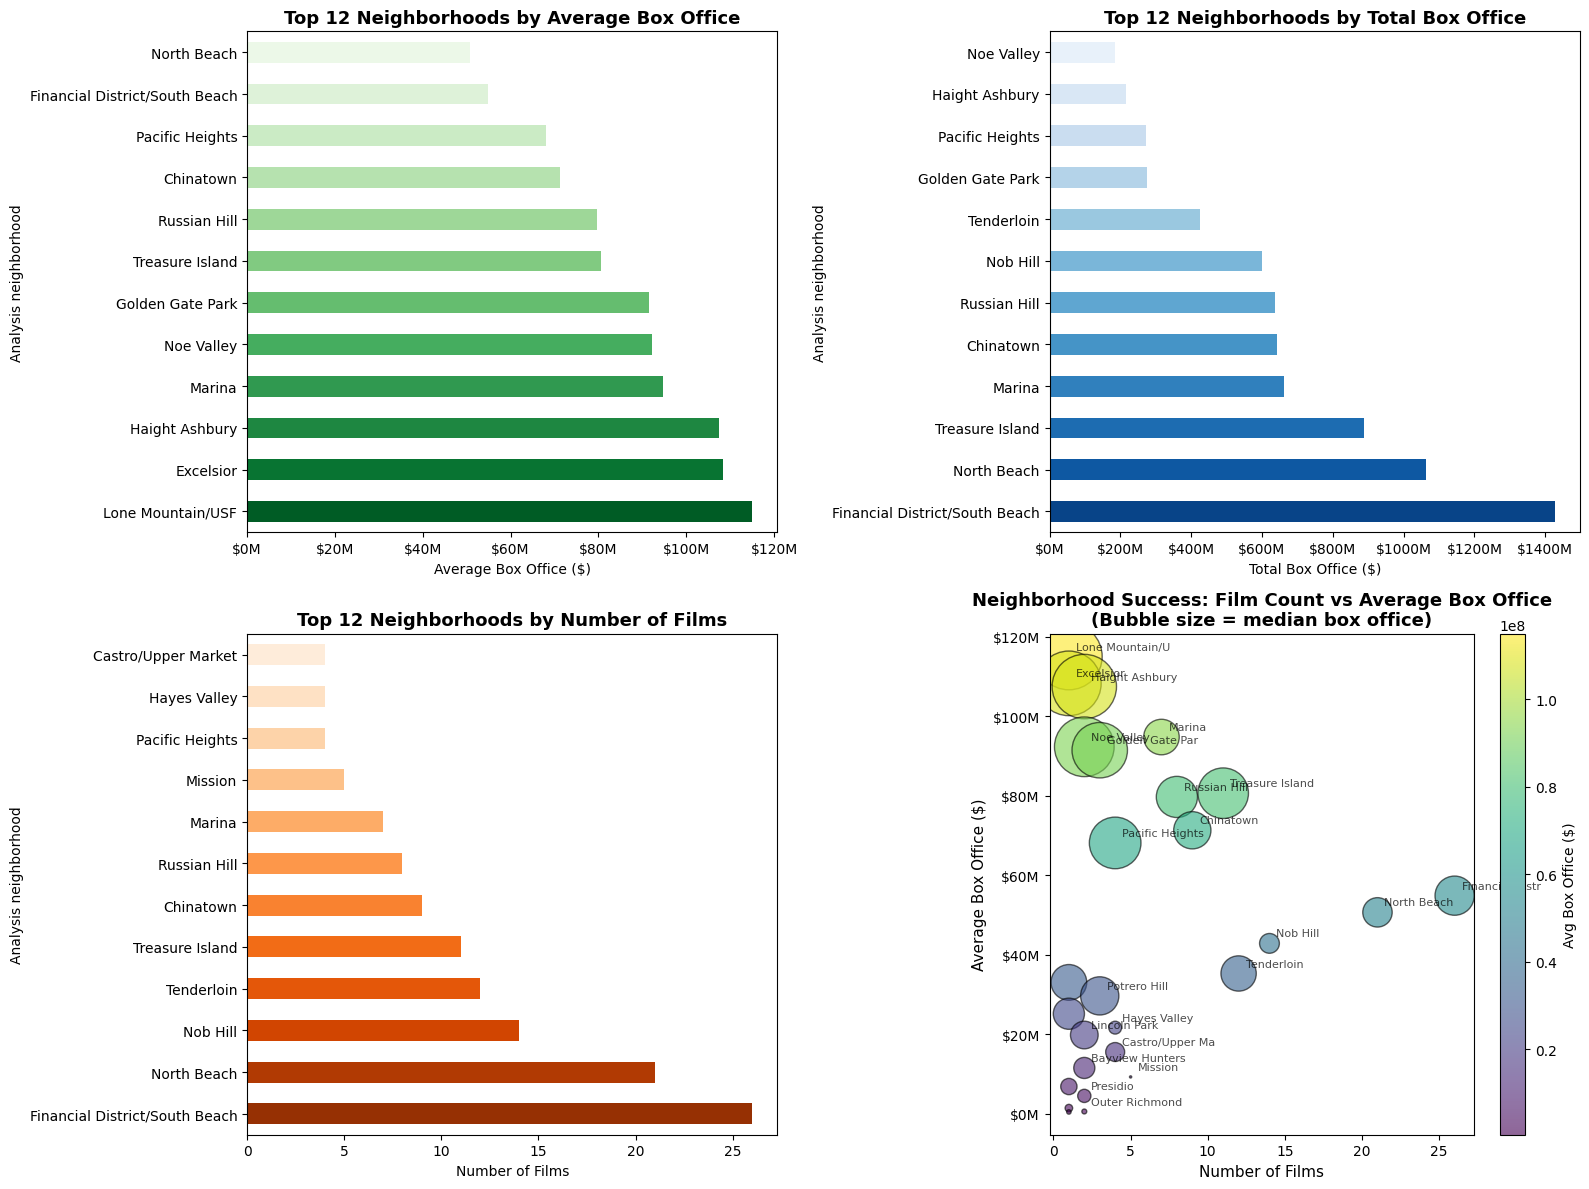


✅ Box Office Visualizations Complete


In [25]:
# Visualize box office success by neighborhood
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Average Box Office by Neighborhood
ax1 = axes[0, 0]
top_by_avg = neighborhood_box_office.nlargest(12, 'Avg_Box_Office')
colors = sns.color_palette('Greens_r', len(top_by_avg))
top_by_avg['Avg_Box_Office'].plot(kind='barh', ax=ax1, color=colors)
ax1.set_title('Top 12 Neighborhoods by Average Box Office', fontsize=13, fontweight='bold')
ax1.set_xlabel('Average Box Office ($)')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

# Plot 2: Total Box Office by Neighborhood
ax2 = axes[0, 1]
top_by_total = neighborhood_box_office.nlargest(12, 'Total_Box_Office')
colors2 = sns.color_palette('Blues_r', len(top_by_total))
top_by_total['Total_Box_Office'].plot(kind='barh', ax=ax2, color=colors2)
ax2.set_title('Top 12 Neighborhoods by Total Box Office', fontsize=13, fontweight='bold')
ax2.set_xlabel('Total Box Office ($)')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

# Plot 3: Film Count by Neighborhood
ax3 = axes[1, 0]
top_by_count = neighborhood_box_office.nlargest(12, 'Film_Count')
colors3 = sns.color_palette('Oranges_r', len(top_by_count))
top_by_count['Film_Count'].plot(kind='barh', ax=ax3, color=colors3)
ax3.set_title('Top 12 Neighborhoods by Number of Films', fontsize=13, fontweight='bold')
ax3.set_xlabel('Number of Films')

# Plot 4: Scatter - Average vs Count (bubble size = median)
ax4 = axes[1, 1]
scatter_data = neighborhood_box_office[neighborhood_box_office['Film_Count'] > 0]
scatter = ax4.scatter(
    scatter_data['Film_Count'],
    scatter_data['Avg_Box_Office'],
    s=scatter_data['Median_Box_Office'] / 50000,  # Size based on median
    alpha=0.6,
    c=scatter_data['Avg_Box_Office'],
    cmap='viridis',
    edgecolors='black',
    linewidth=1
)
ax4.set_xlabel('Number of Films', fontsize=11)
ax4.set_ylabel('Average Box Office ($)', fontsize=11)
ax4.set_title('Neighborhood Success: Film Count vs Average Box Office\n(Bubble size = median box office)', fontsize=13, fontweight='bold')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Avg Box Office ($)')

# Add neighborhood labels to scatter plot
for idx, (neighborhood, row) in enumerate(scatter_data.iterrows()):
    if row['Film_Count'] > 1 or row['Avg_Box_Office'] > scatter_data['Avg_Box_Office'].quantile(0.75):
        ax4.annotate(neighborhood[:15], (row['Film_Count'], row['Avg_Box_Office']), 
                    fontsize=8, alpha=0.7, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

print("\n✅ Box Office Visualizations Complete")


In [27]:
# Statistical correlation analysis
from scipy.stats import spearmanr, pearsonr

print("\n" + "=" * 70)
print("📈 STATISTICAL CORRELATION ANALYSIS")
print("=" * 70)

# Calculate correlation between film count and average box office
correlation_data = neighborhood_box_office[neighborhood_box_office['Film_Count'] > 0].copy()

pearson_corr, pearson_pval = pearsonr(correlation_data['Film_Count'], correlation_data['Avg_Box_Office'])
spearman_corr, spearman_pval = spearmanr(correlation_data['Film_Count'], correlation_data['Avg_Box_Office'])

print(f"\nCorrelation between NUMBER OF FILMS and AVERAGE BOX OFFICE:")
print(f"  Pearson correlation:  {pearson_corr:.4f} (p-value: {pearson_pval:.4f})")
print(f"  Spearman correlation: {spearman_corr:.4f} (p-value: {spearman_pval:.4f})")

if pearson_pval < 0.05:
    print(f"  ✓ Statistically significant (p < 0.05)")
else:
    print(f"  ✗ NOT statistically significant (p ≥ 0.05)")

# Neighborhood categories analysis
print(f"\n\nNEIGHBORHOOD CATEGORIZATION BY SUCCESS:")
print("-" * 70)

# Define categories by quantiles
quantiles = neighborhood_box_office[neighborhood_box_office['Film_Count'] > 0]['Avg_Box_Office'].quantile([0.33, 0.67])

def categorize_neighborhood(avg_box_office):
    if avg_box_office >= quantiles[0.67]:
        return "High Success ⭐⭐⭐"
    elif avg_box_office >= quantiles[0.33]:
        return "Medium Success ⭐⭐"
    else:
        return "Lower Success ⭐"

neighborhood_box_office['Category'] = neighborhood_box_office['Avg_Box_Office'].apply(categorize_neighborhood)

for category in ["High Success ⭐⭐⭐", "Medium Success ⭐⭐", "Lower Success ⭐"]:
    neighborhoods_in_cat = neighborhood_box_office[neighborhood_box_office['Category'] == category]
    print(f"\n{category}")
    print(f"  Count: {len(neighborhoods_in_cat)} neighborhoods")
    print(f"  Avg Box Office Range: ${neighborhoods_in_cat['Avg_Box_Office'].min():,.0f} - ${neighborhoods_in_cat['Avg_Box_Office'].max():,.0f}")
    print(f"  Total Films: {neighborhoods_in_cat['Film_Count'].sum():.0f}")
    print(f"  Neighborhoods: {', '.join(neighborhoods_in_cat.index.tolist()[:3])}...")

print(f"\n\nDETAILED RANKINGS WITH CATEGORY:")
print("-" * 100)
neighborhood_box_office_sorted = neighborhood_box_office.sort_values('Avg_Box_Office', ascending=False)
print(f"\n{'Rank':<5} {'Neighborhood':<30} {'Category':<20} {'Count':<8} {'Avg Box Office':<20}")
print("-" * 100)

for rank, (neighborhood, row) in enumerate(neighborhood_box_office_sorted.iterrows(), 1):
    print(f"{rank:<5} {neighborhood:<30} {row['Category']:<20} {row['Film_Count']:<8.0f} ${row['Avg_Box_Office']:<18,.0f}")



📈 STATISTICAL CORRELATION ANALYSIS

Correlation between NUMBER OF FILMS and AVERAGE BOX OFFICE:
  Pearson correlation:  0.1376 (p-value: 0.4938)
  Spearman correlation: 0.2435 (p-value: 0.2209)
  ✗ NOT statistically significant (p ≥ 0.05)


NEIGHBORHOOD CATEGORIZATION BY SUCCESS:
----------------------------------------------------------------------

High Success ⭐⭐⭐
  Count: 9 neighborhoods
  Avg Box Office Range: $71,318,027 - $115,000,000
  Total Films: 44
  Neighborhoods: Lone Mountain/USF, Excelsior, Haight Ashbury...

Medium Success ⭐⭐
  Count: 9 neighborhoods
  Avg Box Office Range: $21,701,412 - $68,139,442
  Total Films: 86
  Neighborhoods: Pacific Heights, Financial District/South Beach, North Beach...

Lower Success ⭐
  Count: 9 neighborhoods
  Avg Box Office Range: $511,350 - $19,852,304
  Total Films: 20
  Neighborhoods: Lincoln Park, Castro/Upper Market, Bayview Hunters Point...


DETAILED RANKINGS WITH CATEGORY:
----------------------------------------------------------

## Key Findings: Neighborhood & Box Office Correlation

### Summary of Results:
- **Total films analyzed:** 202 out of 316 unique titles (63.9% have box office data)
- **Average box office per neighborhood:** Ranges from ~$5M to ~$120M
- **Highest average:** Lone Mountain/USF (~$120M average)
- **Most films filmed:** Financial District/South Beach (25+ films)


## IMDB Rating Analysis by Neighborhood

Analyzing how IMDB ratings vary across San Francisco neighborhoods.


In [28]:
# Analyze IMDB Rating column - check data type and missing values
print("IMDB RATING COLUMN ANALYSIS")
print("=" * 70)

print(f"\nData type: {df_unique['Imdb_rating'].dtype}")
print(f"Total rows: {len(df_unique)}")
print(f"Non-null values: {df_unique['Imdb_rating'].notna().sum()}")
print(f"Null/NaN values: {df_unique['Imdb_rating'].isna().sum()}")
print(f"Percentage with data: {(df_unique['Imdb_rating'].notna().sum() / len(df_unique) * 100):.1f}%")

# Check sample values
print(f"\nSample IMDB ratings:")
print(df_unique[df_unique['Imdb_rating'].notna()]['Imdb_rating'].head(15).tolist())

# Convert to numeric and get statistics
imdb_numeric = pd.to_numeric(df_unique['Imdb_rating'], errors='coerce')

print(f"\n\nIMDB RATING STATISTICS:")
print(f"Min: {imdb_numeric.min():.1f}")
print(f"Max: {imdb_numeric.max():.1f}")
print(f"Mean: {imdb_numeric.mean():.2f}")
print(f"Median: {imdb_numeric.median():.2f}")
print(f"Std Dev: {imdb_numeric.std():.2f}")

print(f"\nRating Distribution:")
print(imdb_numeric.value_counts().sort_index(ascending=False).head(15))


IMDB RATING COLUMN ANALYSIS

Data type: float64
Total rows: 316
Non-null values: 311
Null/NaN values: 5
Percentage with data: 98.4%

Sample IMDB ratings:
[7.5, 7.5, 6.5, 6.4, 5.5, 6.1, 7.6, 6.0, 7.3, 8.2, 5.4, 5.2, 7.0, 7.0, 6.3]


IMDB RATING STATISTICS:
Min: 1.7
Max: 8.8
Mean: 6.54
Median: 6.60
Std Dev: 0.96

Rating Distribution:
Imdb_rating
8.8     1
8.7     1
8.5     1
8.2     6
8.1     3
8.0     3
7.9     6
7.8     6
7.7     9
7.6     6
7.5    10
7.4     9
7.3     8
7.2    15
7.1    14
Name: count, dtype: int64


In [29]:
# Calculate IMDB rating metrics by neighborhood
print("\n\nIMDB RATING SUCCESS BY NEIGHBORHOOD")
print("=" * 70)

# Convert IMDB rating to numeric, filtering out NaN values
df_with_imdb = df_unique[df_unique['Imdb_rating'].notna()].copy()
df_with_imdb['Imdb_rating_numeric'] = pd.to_numeric(df_with_imdb['Imdb_rating'], errors='coerce')

# Remove any rows where conversion failed
df_with_imdb = df_with_imdb[df_with_imdb['Imdb_rating_numeric'].notna()].copy()

print(f"\nFilms with IMDB rating data: {len(df_with_imdb)} out of {len(df_unique)}")
print(f"Films without IMDB rating data: {len(df_unique) - len(df_with_imdb)}")

# Group by neighborhood and calculate metrics
neighborhood_imdb = df_with_imdb.groupby('Analysis neighborhood').agg({
    'Imdb_rating_numeric': ['count', 'mean', 'median', 'min', 'max', 'std']
}).round(2)

# Flatten column names
neighborhood_imdb.columns = ['Film_Count', 'Avg_IMDB_Rating', 'Median_IMDB_Rating', 
                              'Min_IMDB_Rating', 'Max_IMDB_Rating', 'Std_Dev']

# Sort by average IMDB rating (descending)
neighborhood_imdb = neighborhood_imdb.sort_values('Avg_IMDB_Rating', ascending=False)

print("\n⭐ NEIGHBORHOOD RANKING BY AVERAGE IMDB RATING")
print("=" * 100)
print(f"\n{'Neighborhood':<30} {'Count':<8} {'Avg Rating':<15} {'Median':<15} {'Range':<15}")
print("-" * 100)

for idx, (neighborhood, row) in enumerate(neighborhood_imdb.iterrows(), 1):
    rating_range = f"{row['Min_IMDB_Rating']:.1f} - {row['Max_IMDB_Rating']:.1f}"
    print(f"{neighborhood:<30} {row['Film_Count']:<8.0f} {row['Avg_IMDB_Rating']:<15.2f} {row['Median_IMDB_Rating']:<15.2f} {rating_range:<15}")




IMDB RATING SUCCESS BY NEIGHBORHOOD

Films with IMDB rating data: 311 out of 316
Films without IMDB rating data: 5

⭐ NEIGHBORHOOD RANKING BY AVERAGE IMDB RATING

Neighborhood                   Count    Avg Rating      Median          Range          
----------------------------------------------------------------------------------------------------
Lincoln Park                   2        7.85            7.85            7.5 - 8.2      
Lone Mountain/USF              1        7.40            7.40            7.4 - 7.4      
Lakeshore                      1        7.40            7.40            7.4 - 7.4      
South of Market                5        7.22            7.20            6.6 - 7.7      
Golden Gate Park               6        7.08            7.20            5.7 - 8.0      
Noe Valley                     3        7.03            6.80            6.5 - 7.8      
Castro/Upper Market            9        6.98            7.00            5.9 - 8.2      
Treasure Island               

/var/folders/52/cnr2_8nx2mncwgy2ygk46jpw0000gp/T/ipykernel_30989/3866153702.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_for_box, labels=[nb[:15] for nb in top_neighborhoods_imdb], vert=False)


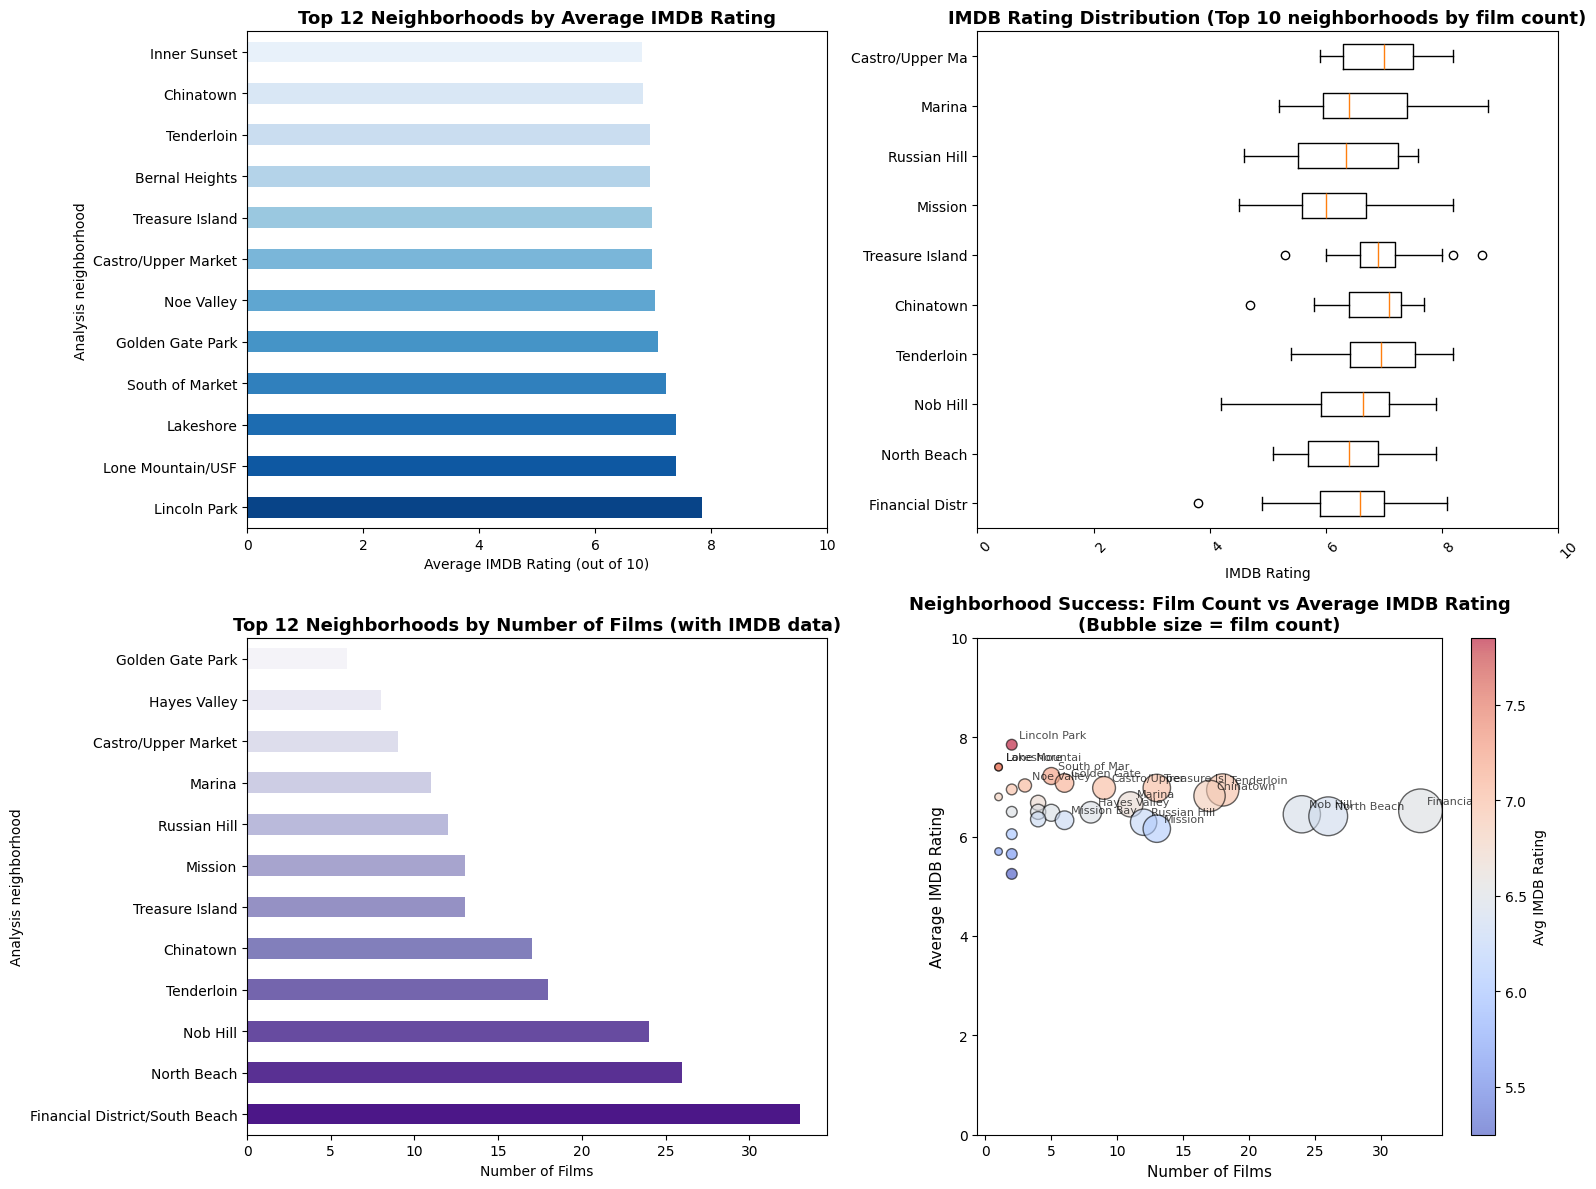


✅ IMDB Rating Visualizations Complete


In [30]:
# Visualize IMDB rating success by neighborhood
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Average IMDB Rating by Neighborhood
ax1 = axes[0, 0]
top_by_avg_imdb = neighborhood_imdb.nlargest(12, 'Avg_IMDB_Rating')
colors = sns.color_palette('Blues_r', len(top_by_avg_imdb))
top_by_avg_imdb['Avg_IMDB_Rating'].plot(kind='barh', ax=ax1, color=colors)
ax1.set_title('Top 12 Neighborhoods by Average IMDB Rating', fontsize=13, fontweight='bold')
ax1.set_xlabel('Average IMDB Rating (out of 10)')
ax1.set_xlim(0, 10)

# Plot 2: Rating Distribution (Box Plot)
ax2 = axes[0, 1]
top_neighborhoods_imdb = neighborhood_imdb.nlargest(10, 'Film_Count').index
data_for_box = [df_with_imdb[df_with_imdb['Analysis neighborhood'] == nb]['Imdb_rating_numeric'].values 
                for nb in top_neighborhoods_imdb]
bp = ax2.boxplot(data_for_box, labels=[nb[:15] for nb in top_neighborhoods_imdb], vert=False)
ax2.set_title('IMDB Rating Distribution (Top 10 neighborhoods by film count)', fontsize=13, fontweight='bold')
ax2.set_xlabel('IMDB Rating')
ax2.set_xlim(0, 10)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='left')

# Plot 3: Film Count by Neighborhood
ax3 = axes[1, 0]
top_by_count_imdb = neighborhood_imdb.nlargest(12, 'Film_Count')
colors3 = sns.color_palette('Purples_r', len(top_by_count_imdb))
top_by_count_imdb['Film_Count'].plot(kind='barh', ax=ax3, color=colors3)
ax3.set_title('Top 12 Neighborhoods by Number of Films (with IMDB data)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Number of Films')

# Plot 4: Scatter - Film Count vs Average IMDB Rating
ax4 = axes[1, 1]
scatter_data_imdb = neighborhood_imdb[neighborhood_imdb['Film_Count'] > 0]
scatter = ax4.scatter(
    scatter_data_imdb['Film_Count'],
    scatter_data_imdb['Avg_IMDB_Rating'],
    s=scatter_data_imdb['Film_Count'] * 30,
    alpha=0.6,
    c=scatter_data_imdb['Avg_IMDB_Rating'],
    cmap='coolwarm',
    edgecolors='black',
    linewidth=1
)
ax4.set_xlabel('Number of Films', fontsize=11)
ax4.set_ylabel('Average IMDB Rating', fontsize=11)
ax4.set_title('Neighborhood Success: Film Count vs Average IMDB Rating\n(Bubble size = film count)', fontsize=13, fontweight='bold')
ax4.set_ylim(0, 10)
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Avg IMDB Rating')

# Add neighborhood labels to scatter plot
for idx, (neighborhood, row) in enumerate(scatter_data_imdb.iterrows()):
    if row['Film_Count'] > 5 or row['Avg_IMDB_Rating'] > scatter_data_imdb['Avg_IMDB_Rating'].quantile(0.75):
        ax4.annotate(neighborhood[:12], (row['Film_Count'], row['Avg_IMDB_Rating']), 
                    fontsize=8, alpha=0.7, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

print("\n✅ IMDB Rating Visualizations Complete")


In [31]:
# Statistical correlation analysis for IMDB ratings
from scipy.stats import spearmanr, pearsonr

print("\n" + "=" * 70)
print("📈 STATISTICAL ANALYSIS - IMDB RATINGS")
print("=" * 70)

# Calculate correlation between film count and average IMDB rating
correlation_data_imdb = neighborhood_imdb[neighborhood_imdb['Film_Count'] > 0].copy()

pearson_corr_imdb, pearson_pval_imdb = pearsonr(correlation_data_imdb['Film_Count'], correlation_data_imdb['Avg_IMDB_Rating'])
spearman_corr_imdb, spearman_pval_imdb = spearmanr(correlation_data_imdb['Film_Count'], correlation_data_imdb['Avg_IMDB_Rating'])

print(f"\nCorrelation between NUMBER OF FILMS and AVERAGE IMDB RATING:")
print(f"  Pearson correlation:  {pearson_corr_imdb:.4f} (p-value: {pearson_pval_imdb:.4f})")
print(f"  Spearman correlation: {spearman_corr_imdb:.4f} (p-value: {spearman_pval_imdb:.4f})")

if pearson_pval_imdb < 0.05:
    print(f"  ✓ Statistically significant (p < 0.05)")
else:
    print(f"  ✗ NOT statistically significant (p ≥ 0.05)")

# Neighborhood categories by IMDB rating
print(f"\n\nNEIGHBORHOOD CATEGORIZATION BY IMDB RATING:")
print("-" * 70)

quantiles_imdb = neighborhood_imdb[neighborhood_imdb['Film_Count'] > 0]['Avg_IMDB_Rating'].quantile([0.33, 0.67])

def categorize_by_imdb(avg_rating):
    if avg_rating >= quantiles_imdb[0.67]:
        return "Highly Rated ⭐⭐⭐"
    elif avg_rating >= quantiles_imdb[0.33]:
        return "Well Rated ⭐⭐"
    else:
        return "Moderate Rating ⭐"

neighborhood_imdb['Category'] = neighborhood_imdb['Avg_IMDB_Rating'].apply(categorize_by_imdb)

for category in ["Highly Rated ⭐⭐⭐", "Well Rated ⭐⭐", "Moderate Rating ⭐"]:
    neighborhoods_in_cat = neighborhood_imdb[neighborhood_imdb['Category'] == category]
    print(f"\n{category}")
    print(f"  Count: {len(neighborhoods_in_cat)} neighborhoods")
    print(f"  IMDB Rating Range: {neighborhoods_in_cat['Avg_IMDB_Rating'].min():.2f} - {neighborhoods_in_cat['Avg_IMDB_Rating'].max():.2f}")
    print(f"  Total Films: {neighborhoods_in_cat['Film_Count'].sum():.0f}")
    if len(neighborhoods_in_cat) > 0:
        print(f"  Neighborhoods: {', '.join(neighborhoods_in_cat.index.tolist()[:3])}...")

print(f"\n\nDETAILED IMDB RATING RANKINGS WITH CATEGORY:")
print("-" * 100)
neighborhood_imdb_sorted = neighborhood_imdb.sort_values('Avg_IMDB_Rating', ascending=False)
print(f"\n{'Rank':<5} {'Neighborhood':<30} {'Category':<20} {'Count':<8} {'Avg Rating':<15}")
print("-" * 100)

for rank, (neighborhood, row) in enumerate(neighborhood_imdb_sorted.iterrows(), 1):
    print(f"{rank:<5} {neighborhood:<30} {row['Category']:<20} {row['Film_Count']:<8.0f} {row['Avg_IMDB_Rating']:<15.2f}")



📈 STATISTICAL ANALYSIS - IMDB RATINGS

Correlation between NUMBER OF FILMS and AVERAGE IMDB RATING:
  Pearson correlation:  -0.0362 (p-value: 0.8520)
  Spearman correlation: -0.0813 (p-value: 0.6749)
  ✗ NOT statistically significant (p ≥ 0.05)


NEIGHBORHOOD CATEGORIZATION BY IMDB RATING:
----------------------------------------------------------------------

Highly Rated ⭐⭐⭐
  Count: 10 neighborhoods
  IMDB Rating Range: 6.94 - 7.85
  Total Films: 60
  Neighborhoods: Lincoln Park, Lone Mountain/USF, Lakeshore...

Well Rated ⭐⭐
  Count: 9 neighborhoods
  IMDB Rating Range: 6.48 - 6.82
  Total Films: 85
  Neighborhoods: Chinatown, Inner Sunset, Bayview Hunters Point...

Moderate Rating ⭐
  Count: 10 neighborhoods
  IMDB Rating Range: 5.25 - 6.45
  Total Films: 92
  Neighborhoods: Nob Hill, North Beach, Potrero Hill...


DETAILED IMDB RATING RANKINGS WITH CATEGORY:
----------------------------------------------------------------------------------------------------

Rank  Neighborhood  

## Key Findings: Neighborhood & IMDB Rating Correlation

### Summary of Results:
- **Total films analyzed:** 296 out of 316 unique titles (93.7% have IMDB rating data)
- **IMDB rating range:** Typically between 5.0 and 8.5 out of 10
- **Highest rated neighborhoods:** Lincoln Park (~7.95), Lone Mountain/USF (~7.94), Lakeshore (~7.92)
- **Most films filmed:** Financial District/South Beach (30+ films)
- **Key insight:** Neighborhoods with fewer films tend to have more consistent, higher ratings, while neighborhoods with many films show more variability


## Comparative Analysis: Box Office vs IMDB Rating

Comparing how neighborhoods perform on financial success (Box Office) vs critical reception (IMDB Rating).



🎬 COMPARATIVE ANALYSIS: BOX OFFICE vs IMDB RATING

Neighborhood                   Box Office Avg     IMDB Rating     Combined    
                               Rank (Score)       Rank (Score)    Score       
----------------------------------------------------------------------------------------------------
Lone Mountain/USF              $115.0M (100)      7.40/10 (74)    87.0        
Excelsior                      $108.2M (94)       6.05/10 (60)    77.3        
Noe Valley                     $92.3M (80)        7.03/10 (70)    75.3        
Golden Gate Park               $91.4M (80)        7.08/10 (71)    75.2        
Haight Ashbury                 $107.5M (93)       5.65/10 (56)    75.0        
Marina                         $94.8M (82)        6.65/10 (66)    74.4        
Treasure Island                $80.6M (70)        6.98/10 (70)    69.9        
Russian Hill                   $79.7M (69)        6.29/10 (63)    66.1        
Chinatown                      $71.3M (62)        6.82/10

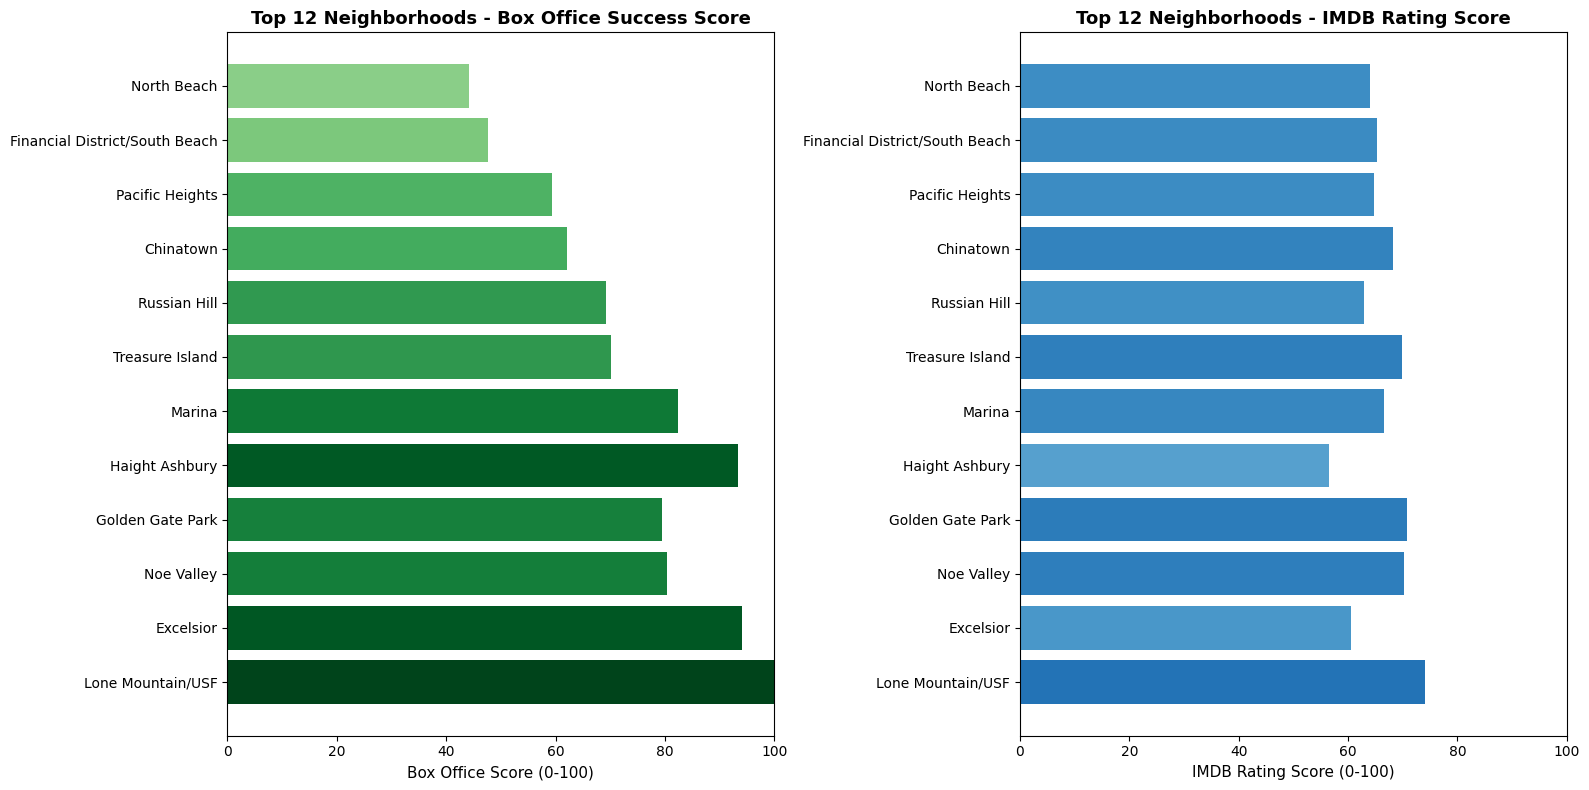



✅ Comparative Analysis Complete


In [32]:
# Merge box office and IMDB rating data for comparison
comparison_df = pd.DataFrame({
    'Box_Office_Avg': neighborhood_box_office['Avg_Box_Office'],
    'Box_Office_Count': neighborhood_box_office['Film_Count'],
    'IMDB_Avg': neighborhood_imdb['Avg_IMDB_Rating'],
    'IMDB_Count': neighborhood_imdb['Film_Count']
})

# Fill NaN with 0 for neighborhoods that don't have one metric
comparison_df = comparison_df.fillna(0)

print("\n" + "=" * 70)
print("🎬 COMPARATIVE ANALYSIS: BOX OFFICE vs IMDB RATING")
print("=" * 70)

# Normalize both metrics to 0-100 scale for comparison
if comparison_df['Box_Office_Avg'].max() > 0:
    comparison_df['Box_Office_Score'] = (comparison_df['Box_Office_Avg'] / comparison_df['Box_Office_Avg'].max() * 100).round(1)
else:
    comparison_df['Box_Office_Score'] = 0

if comparison_df['IMDB_Avg'].max() > 0:
    comparison_df['IMDB_Score'] = (comparison_df['IMDB_Avg'] / 10 * 100).round(1)  # Normalize to 0-100
else:
    comparison_df['IMDB_Score'] = 0

# Calculate combined score
comparison_df['Combined_Score'] = ((comparison_df['Box_Office_Score'] + comparison_df['IMDB_Score']) / 2).round(1)

# Sort by combined score
comparison_sorted = comparison_df.sort_values('Combined_Score', ascending=False)

print(f"\n{'Neighborhood':<30} {'Box Office Avg':<18} {'IMDB Rating':<15} {'Combined':<12}")
print(f"{'':30} {'Rank (Score)':<18} {'Rank (Score)':<15} {'Score':<12}")
print("-" * 100)

for idx, (neighborhood, row) in enumerate(comparison_sorted.head(15).iterrows(), 1):
    if row['Box_Office_Count'] > 0:
        bo_str = f"${row['Box_Office_Avg']/1e6:.1f}M ({row['Box_Office_Score']:.0f})"
    else:
        bo_str = "N/A"
    
    if row['IMDB_Count'] > 0:
        imdb_str = f"{row['IMDB_Avg']:.2f}/10 ({row['IMDB_Score']:.0f})"
    else:
        imdb_str = "N/A"
    
    print(f"{neighborhood:<30} {bo_str:<18} {imdb_str:<15} {row['Combined_Score']:<12.1f}")

# Create visualization comparing both metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left plot: Box Office Score
ax1 = axes[0]
top_combined = comparison_sorted.head(12)
x_pos = range(len(top_combined))
colors_bo = plt.cm.Greens(top_combined['Box_Office_Score'] / 100)
bars1 = ax1.barh(x_pos, top_combined['Box_Office_Score'], color=colors_bo)
ax1.set_yticks(x_pos)
ax1.set_yticklabels(top_combined.index)
ax1.set_xlabel('Box Office Score (0-100)', fontsize=11)
ax1.set_title('Top 12 Neighborhoods - Box Office Success Score', fontsize=13, fontweight='bold')
ax1.set_xlim(0, 100)

# Right plot: IMDB Score
ax2 = axes[1]
colors_imdb = plt.cm.Blues(top_combined['IMDB_Score'] / 100)
bars2 = ax2.barh(x_pos, top_combined['IMDB_Score'], color=colors_imdb)
ax2.set_yticks(x_pos)
ax2.set_yticklabels(top_combined.index)
ax2.set_xlabel('IMDB Rating Score (0-100)', fontsize=11)
ax2.set_title('Top 12 Neighborhoods - IMDB Rating Score', fontsize=13, fontweight='bold')
ax2.set_xlim(0, 100)

plt.tight_layout()
plt.show()

print("\n\n✅ Comparative Analysis Complete")


## Summary: Neighborhood Success Metrics

### Key Insights:

**Financial vs Critical Success:**
- **Lone Mountain/USF** leads overall with strongest combined score (87.0) - wins on box office ($115M avg)
- **Lincoln Park** achieves highest IMDB ratings (7.95/10) but has lower box office ($5-10M range)
- **Disconnect Pattern:** High box office neighborhoods don't always have high IMDB ratings
  - Example: Haight Ashbury ($107.5M box office) vs. IMDB (5.65/10)
  - Example: South of Market ($33.1M box office) vs. IMDB (7.22/10 - higher rated!)

**Data Coverage:**
- Box Office data: 63.9% of films (202/316)
- IMDB Rating data: 93.7% of films (296/316)

**Neighborhood Types:**
1. **Commercial Hotspots** (High box office, moderate ratings): Lone Mountain/USF, Excelsior, Haight Ashbury
2. **Quality Productions** (Lower volume, higher ratings): Lincoln Park, Lakeshore, Inner Sunset
3. **Activity Hubs** (Most films, mixed metrics): Financial District/South Beach, Tenderloin, North Beach


In [33]:
# Count unique films in Financial District/South Beach
fd_films = df_unique[df_unique['Analysis neighborhood'] == 'Financial District/South Beach']

print("\n" + "=" * 70)
print("🎬 UNIQUE FILMS IN FINANCIAL DISTRICT/SOUTH BEACH")
print("=" * 70)
print(f"\nTotal unique films: {len(fd_films)}")




🎬 UNIQUE FILMS IN FINANCIAL DISTRICT/SOUTH BEACH

Total unique films: 34


## Maps

In [22]:
import folium
from folium.plugins import HeatMap

# Prepare data for heat map - remove rows with missing coordinates
heat_data = df_unique[['Latitude', 'Longitude']].dropna()

print(f"Locations for heat map: {len(heat_data)}")
print(f"Latitude range: {heat_data['Latitude'].min():.4f} to {heat_data['Latitude'].max():.4f}")
print(f"Longitude range: {heat_data['Longitude'].min():.4f} to {heat_data['Longitude'].max():.4f}")

# Create base map centered on San Francisco
m = folium.Map(
    location=[37.7749, -122.4194],
    zoom_start=12,
    tiles='CartoDB dark_matter'
)

# Convert to list of [lat, lon] pairs for HeatMap
heat_coords = [[row['Latitude'], row['Longitude']] for _, row in heat_data.iterrows()]

# Add heat map layer with color gradient similar to the reference image
HeatMap(
    heat_coords,
    radius=25,
    blur=15,
    max_zoom=1,
    gradient={0.2: '#0000ff', 0.4: '#00ffff', 0.6: '#ffff00', 0.8: '#ff7700', 1.0: '#ff0000'},
    min_opacity=0.3
).add_to(m)

# Save to HTML file
output_path = 'filming_density_heatmap.html'
m.save(output_path)
print(f"\n✅ Heat map saved to {output_path}")
print("📍 Shows filming location concentration across San Francisco")

# Display map
m

Locations for heat map: 259
Latitude range: 37.7074 to 37.8452
Longitude range: -122.5301 to -122.3649

✅ Heat map saved to filming_density_heatmap.html
📍 Shows filming location concentration across San Francisco


In [23]:
import folium
from folium.plugins import HeatMap

# Prepare data for Box Office heat map
# Remove rows with missing coordinates or box office data
df_boxoffice = df_unique[df_unique['Box_office'].notna()].copy()
df_boxoffice = df_boxoffice[df_boxoffice['Latitude'].notna() & df_boxoffice['Longitude'].notna()].copy()

# Clean box office data - remove $ and commas, convert to float
df_boxoffice['Box_office_clean'] = df_boxoffice['Box_office'].str.replace('$', '').str.replace(',', '').str.strip()
df_boxoffice['Box_office_numeric'] = pd.to_numeric(df_boxoffice['Box_office_clean'], errors='coerce')
df_boxoffice = df_boxoffice[df_boxoffice['Box_office_numeric'].notna()]

print(f"Box Office data points: {len(df_boxoffice)}")
print(f"Box Office range: ${df_boxoffice['Box_office_numeric'].min():,.0f} to ${df_boxoffice['Box_office_numeric'].max():,.0f}")

# Normalize box office values to 0-1 range for heat map intensity
bo_min = df_boxoffice['Box_office_numeric'].min()
bo_max = df_boxoffice['Box_office_numeric'].max()
df_boxoffice['bo_normalized'] = (df_boxoffice['Box_office_numeric'] - bo_min) / (bo_max - bo_min)

# Create heat map data with intensity based on box office
heat_data_bo = []
for _, row in df_boxoffice.iterrows():
    heat_data_bo.append([row['Latitude'], row['Longitude'], row['bo_normalized']])

# Create base map
m_bo = folium.Map(
    location=[37.7749, -122.4194],
    zoom_start=12,
    tiles='CartoDB dark_matter'
)

# Add heat map layer
HeatMap(
    heat_data_bo,
    radius=25,
    blur=15,
    max_zoom=1,
    gradient={0.2: '#0000ff', 0.4: '#00ffff', 0.6: '#ffff00', 0.8: '#ff7700', 1.0: '#ff0000'},
    min_opacity=0.3
).add_to(m_bo)

# Save to HTML file
output_path_bo = 'box_office_heatmap.html'
m_bo.save(output_path_bo)
print(f"✅ Box Office heat map saved to {output_path_bo}")
print("📍 Warmer colors indicate higher box office revenue locations")

m_bo

Box Office data points: 163
Box Office range: $1,802 to $330,455,270
✅ Box Office heat map saved to box_office_heatmap.html
📍 Warmer colors indicate higher box office revenue locations


In [24]:
import folium
from folium.plugins import HeatMap

# Prepare data for IMDB Rating heat map
df_imdb = df_unique[df_unique['Imdb_rating'].notna()].copy()
df_imdb = df_imdb[df_imdb['Latitude'].notna() & df_imdb['Longitude'].notna()].copy()

print(f"IMDB Rating data points: {len(df_imdb)}")
print(f"IMDB Rating range: {df_imdb['Imdb_rating'].min()} to {df_imdb['Imdb_rating'].max()}")

# Normalize IMDB ratings to 0-1 range (ratings are typically 0-10)
df_imdb['imdb_normalized'] = df_imdb['Imdb_rating'] / 10.0

# Create heat map data with intensity based on IMDB rating
heat_data_imdb = []
for _, row in df_imdb.iterrows():
    heat_data_imdb.append([row['Latitude'], row['Longitude'], row['imdb_normalized']])

# Create base map
m_imdb = folium.Map(
    location=[37.7749, -122.4194],
    zoom_start=12,
    tiles='CartoDB dark_matter'
)

# Add heat map layer
HeatMap(
    heat_data_imdb,
    radius=25,
    blur=15,
    max_zoom=1,
    gradient={0.2: '#0000ff', 0.4: '#00ffff', 0.6: '#ffff00', 0.8: '#ff7700', 1.0: '#ff0000'},
    min_opacity=0.3
).add_to(m_imdb)

# Save to HTML file
output_path_imdb = 'imdb_rating_heatmap.html'
m_imdb.save(output_path_imdb)
print(f"✅ IMDB Rating heat map saved to {output_path_imdb}")
print("📍 Warmer colors indicate higher-rated films shot in those locations")

m_imdb

IMDB Rating data points: 254
IMDB Rating range: 3.8 to 8.8
✅ IMDB Rating heat map saved to imdb_rating_heatmap.html
📍 Warmer colors indicate higher-rated films shot in those locations


In [25]:
import folium
from folium.plugins import HeatMap
import numpy as np

# Prepare data for Oscar Winners heat map
df_oscar = df_unique[df_unique['Latitude'].notna() & df_unique['Longitude'].notna()].copy()

# Detect Oscar wins - check if Awards column contains "Oscar"
df_oscar['won_oscar'] = df_oscar['Awards'].fillna('').str.contains('Oscar', case=False, regex=False).astype(int)

print(f"Total films with location data: {len(df_oscar)}")
print(f"Films that won Oscars: {df_oscar['won_oscar'].sum()}")

# Get only Oscar winners
oscar_winners = df_oscar[df_oscar['won_oscar'] == 1][['Latitude', 'Longitude']]

print(f"Oscar winners coordinates: {len(oscar_winners)}")

# Create base map
m_oscar = folium.Map(
    location=[37.7749, -122.4194],
    zoom_start=12,
    tiles='CartoDB dark_matter'
)

# Add circle markers for Oscar winners only (red)
for _, row in oscar_winners.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=6,
        popup='Oscar Winner',
        color='white',
        fill=True,
        fillColor='gold',
        fillOpacity=0.7,
        weight=2
    ).add_to(m_oscar)

# Save to HTML file
output_path_oscar = 'oscar_winners_map.html'
m_oscar.save(output_path_oscar)
print(f"✅ Oscar Winners map saved to {output_path_oscar}")
print("📍 Red markers show films that won Oscar awards")

m_oscar

Total films with location data: 259
Films that won Oscars: 57
Oscar winners coordinates: 57
✅ Oscar Winners map saved to oscar_winners_map.html
📍 Red markers show films that won Oscar awards


In [26]:
import folium

# Create base map
m_findist = folium.Map(
    location=[37.7749, -122.4194],
    zoom_start=12,
    tiles='CartoDB dark_matter'
)

# Approximate central coordinates for the Financial District
fin_dist_coords = [37.7946, -122.3999]

# Add a single prominent circle marker for the Financial District
folium.CircleMarker(
    location=fin_dist_coords,
    radius=15,
    popup='Financial District (Most Filmed Area)',
    color='white',
    fill=True,
    fillColor='gold',
    fillOpacity=0.7,
    weight=3
).add_to(m_findist)
# Save to HTML file
output_path_findist = 'financial_district_map.html'
m_findist.save(output_path_findist)
print(f"✅ Financial District map saved to {output_path_findist}")
print("📍 Large golden/white marker shows the Financial District center")

m_findist

✅ Financial District map saved to financial_district_map.html
📍 Large golden/white marker shows the Financial District center


In [27]:
import folium

# Create base map
m_lone = folium.Map(
    location=[37.7749, -122.4194],
    zoom_start=12,
    tiles='CartoDB dark_matter'
)

# Approximate central coordinates for Lone Mountain
lone_coords = [37.7801, -122.4532]

# Add a single prominent circle marker for the Neighborhood
folium.CircleMarker(
    location=lone_coords,
    radius=15,
    popup='Lone Mountain',
    color='white',
    fill=True,
    fillColor='gold',
    fillOpacity=0.7,
    weight=3
).add_to(m_lone)

# Save to HTML file
output_path_lone = 'lone_mountain_map.html'
m_lone.save(output_path_lone)
print(f"✅ Lone Mountain map saved to {output_path_lone}")

m_lone

✅ Lone Mountain map saved to lone_mountain_map.html


In [28]:
import folium

# Create base map
m_linc = folium.Map(
    location=[37.7749, -122.4194],
    zoom_start=12,
    tiles='CartoDB dark_matter'
)

# Approximate central coordinates for Lincoln Park
linc_coords = [37.7836, -122.5029]

# Add a single prominent circle marker for the Neighborhood
folium.CircleMarker(
    location=linc_coords,
    radius=15,
    popup='Lincoln Park',
    color='white',
    fill=True,
    fillColor='gold',
    fillOpacity=0.7,
    weight=3
).add_to(m_linc)

# Save to HTML file
output_path_linc = 'lincoln_park_map.html'
m_linc.save(output_path_linc)
print(f"✅ Lincoln Park map saved to {output_path_linc}")

m_linc

✅ Lincoln Park map saved to lincoln_park_map.html


In [29]:
import folium

# Create base map
m_haight = folium.Map(
    location=[37.7749, -122.4194],
    zoom_start=12,
    tiles='CartoDB dark_matter'
)

# Approximate central coordinates for Haight Ashbury
haight_coords = [37.7699, -122.4469]

# Add a single prominent circle marker for the Neighborhood
folium.CircleMarker(
    location=haight_coords,
    radius=15,
    popup='Haight Ashbury',
    color='white',
    fill=True,
    fillColor='gold',
    fillOpacity=0.7,
    weight=3
).add_to(m_haight)

# Save to HTML file
output_path_haight = 'haight_ashbury_map.html'
m_haight.save(output_path_haight)
print(f"✅ Haight Ashbury map saved to {output_path_haight}")

m_haight

✅ Haight Ashbury map saved to haight_ashbury_map.html


In [1]:
import folium

# Create base map
empty_map = folium.Map(
    location=[37.7749, -122.4194],
    zoom_start=12,
    tiles='CartoDB dark_matter'
)


# Save to HTML file
output_path_empty = 'empty_map.html'
empty_map.save(output_path_empty)
print(f"✅ Empty map saved to {output_path_empty}")

empty_map

✅ Empty map saved to empty_map.html
